# 데이터 불러오기

In [1]:
from google.colab import drive
drive.mount('/content/drive')
import os
os.chdir('/content/drive/MyDrive/BigContest_JSH/BigContest/data')

import dask.dataframe as dd
import time
import pandas as pd

import matplotlib.pyplot as plt
import numpy as np

Mounted at /content/drive


/usr/local/lib/python3.10/dist-packages/dask/dataframe/__init__.py:42: FutureWarning: 
Dask dataframe query planning is disabled because dask-expr is not installed.

You can install it with `pip install dask[dataframe]` or `conda install dask`.
This will raise in a future version.

  warnings.warn(msg, FutureWarning)


In [2]:
!pip install koreanize-matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 45.7 MB/s eta 0:00:00


In [3]:
od=dd.read_csv('OD_all.csv', assume_missing = True, header = 0)
stay=dd.read_csv('stay_all.csv', assume_missing=True, header=0)

In [4]:
modal_cd = {0: '차량',
            1: '시내버스',
            2: '지하철',
            3: '도보',
            4: '기타',
            5: '철도',
            6: '시외고속버스',
            7: '항공기',
            'nan': '-'}
od.modal=od['modal'].map(modal_cd)

In [5]:
purpose_cd = {0: '귀가',
              1: '업무',
              2: '학업',
              3: '쇼핑여가',
              4: '기타',
              5: '여행'}
od.origin_purpose=od['origin_purpose'].map(purpose_cd)
od.dest_purpose=od['dest_purpose'].map(purpose_cd)

In [6]:
stay.purpose=stay['purpose'].map(purpose_cd)

In [7]:
stay = stay.drop(columns = 'Unnamed: 0')
stay.head()

,hdong_cd,date,time,gender,age,purpose,stay_cnts
0,2.811054e+09,20230901.0,13:00,1.0,6.0,귀가,754.0
1,4.831055e+09,20230901.0,21:00,0.0,4.0,귀가,878.0
2,4.117360e+09,20230901.0,12:00,1.0,1.0,귀가,904.0
3,1.156054e+09,20230901.0,14:00,0.0,4.0,업무,13729.0
4,4.713059e+09,20230901.0,19:00,0.0,4.0,귀가,946.0


In [8]:
# 지수 표기 형식으로 된 'origin_hdong_cd' 값을 정수형으로 변환
od['origin_hdong_cd'] = od['origin_hdong_cd'].astype(int)
od['dest_hdong_cd'] = od['dest_hdong_cd'].astype(int)

In [9]:
stay['hdong_cd'] = stay['hdong_cd'].astype(int)

In [10]:
origin_hdong_map = {
    1156054000.0: '여의동',
    4575034000.0: '임실 성수면',
    5115057200.0: '강릉시 포남2동',
    5115058000.0: '강릉시 초당동',
    2635052000.0: '부산광역시 해운대구 우2동',
    3020055000.0: '대전광역시 유성구 도룡동'
}

In [11]:
origin_hdong_codes = list(origin_hdong_map.keys())

In [12]:
filtered_data = od[od['origin_hdong_cd'].isin(origin_hdong_codes)]



In [13]:
filtered_stay=stay[stay['hdong_cd'].isin(origin_hdong_codes)]

In [14]:
od_data_pd = filtered_data.compute()

In [15]:
stay_data_pd=filtered_stay.compute()

In [16]:
stay_data_pd['출발지역']=stay_data_pd['hdong_cd'].map(origin_hdong_map)

In [17]:
od_data_pd['출발지역'] = od_data_pd['origin_hdong_cd'].map(origin_hdong_map)

In [18]:
dtype_optimized = {
    'origin_hdong_cd': 'int64',
    'dest_hdong_cd': 'int64',
    'date': 'int64',
    'start_time': 'object',
    'end_time': 'object',
    'gender': 'int8',
    'age': 'int8',
    'modal': 'int64',              # 이미 결측치 처리 후 int64로 변환됨
    'origin_purpose': 'int64',     # 이미 결측치 처리 후 int64로 변환됨
    'dest_purpose': 'int8',
    'od_dist_avg': 'int32',
    'od_duration_avg': 'int32',
    'od_cnts': 'int32'
}

In [19]:
od_data = od.astype(dtype_optimized)

In [20]:
od_data_pd.origin_hdong_cd = od_data_pd.origin_hdong_cd.astype('str')
od_data_pd.dest_hdong_cd = od_data_pd.dest_hdong_cd.astype('str')
od_data_pd.date = od_data_pd.date.astype('int')
od_data_pd.modal = od_data_pd.modal.astype('str')
od_data_pd.origin_purpose = od_data_pd.origin_purpose.astype('str')
od_data_pd.dest_purpose = od_data_pd.dest_purpose.astype('str')

In [21]:
od_data_pd

,origin_hdong_cd,dest_hdong_cd,date,start_time,end_time,gender,age,modal,origin_purpose,dest_purpose,od_dist_avg,od_duration_avg,od_cnts,출발지역
107,3020055000,4372039000,20230901,08:00,09:00,0.0,3.0,차량,기타,기타,153144.0,56.0,7.0,대전광역시 유성구 도룡동
108,2635052000,2635052500,20230901,15:00,16:00,1.0,5.0,차량,귀가,귀가,27621.0,67.0,7.0,부산광역시 해운대구 우2동
330,1156054000,4180032000,20230901,16:00,20:00,1.0,2.0,차량,기타,여행,234893.0,233.0,8.0,여의동
464,1156054000,1156056000,20230901,18:00,18:00,0.0,4.0,차량,업무,쇼핑여가,10256.0,24.0,7.0,여의동
494,1156054000,1150051000,20230901,17:00,18:00,1.0,3.0,차량,업무,귀가,27053.0,56.0,12.0,여의동
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
714024,2635052000,2635051000,20231015,09:00,09:00,1.0,2.0,차량,기타,귀가,12756.0,17.0,5.0,부산광역시 해운대구 우2동
714284,1156054000,4122031000,20231015,17:00,20:00,1.0,1.0,철도,여행,기타,216184.0,178.0,5.0,여의동
714488,2635052000,2635051000,20231015,13:00,13:00,0.0,3.0,차량,기타,기타,6656.0,9.0,5.0,부산광역시 해운대구 우2동
714797,1156054000,4113559000,20231015,19:00,20:00,1.0,4.0,차량,업무,귀가,151532.0,75.0,5.0,여의동


In [22]:
# festival_periods = {
#     1156054000.0: ('20231007', '20231007'),              # 여의동: 2023-10-07
#     4575034000.0: ('20231006', '20231009'),              # 임실 성수면: 2023-10-06 ~ 2023-10-09
#     5115057200.0: ('20231012', '20231015'),              # 강릉시 포남2동: 2023-10-12 ~ 2023-10-15
#     5115058000.0: ('20231012', '20231015'),              # 강릉시 초당동: 2023-10-12 ~ 2023-10-15
#     2635052000.0: ('20231004', '20231013'),              # 부산광역시 해운대구 우2동: 2023-10-04 ~ 2023-10-13
#     3020055000.0: ('20231008', '20231010')               # 대전광역시 유성구 도룡동: 2023-10-08 ~ 2023-10-10
# }

In [23]:
df = od_data_pd[
    (od_data_pd['origin_purpose'].isin(['쇼핑여가', '기타', '여행'])) &
    (od_data_pd['dest_purpose'].isin(['쇼핑여가', '기타', '여행']))
]
df

,origin_hdong_cd,dest_hdong_cd,date,start_time,end_time,gender,age,modal,origin_purpose,dest_purpose,od_dist_avg,od_duration_avg,od_cnts,출발지역
107,3020055000,4372039000,20230901,08:00,09:00,0.0,3.0,차량,기타,기타,153144.0,56.0,7.0,대전광역시 유성구 도룡동
330,1156054000,4180032000,20230901,16:00,20:00,1.0,2.0,차량,기타,여행,234893.0,233.0,8.0,여의동
1416,3020055000,3023052500,20230901,08:00,09:00,0.0,5.0,차량,기타,기타,14091.0,31.0,8.0,대전광역시 유성구 도룡동
1990,2635052000,4831039000,20230901,19:00,22:00,1.0,3.0,차량,기타,여행,319689.0,170.0,7.0,부산광역시 해운대구 우2동
2484,3020055000,3020054000,20230901,17:00,18:00,0.0,2.0,차량,쇼핑여가,기타,35412.0,49.0,7.0,대전광역시 유성구 도룡동
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
711330,2635052000,2635051000,20231015,18:00,18:00,0.0,2.0,시내버스,기타,기타,12077.0,13.0,5.0,부산광역시 해운대구 우2동
713624,2635052000,2647072000,20231015,19:00,19:00,1.0,2.0,차량,쇼핑여가,기타,30006.0,44.0,5.0,부산광역시 해운대구 우2동
713848,2635052000,2635051000,20231015,14:00,15:00,0.0,3.0,도보,기타,기타,27033.0,62.0,5.0,부산광역시 해운대구 우2동
714284,1156054000,4122031000,20231015,17:00,20:00,1.0,1.0,철도,여행,기타,216184.0,178.0,5.0,여의동


In [24]:
dff = od_data_pd[
    (od_data_pd['origin_purpose'].isin(['쇼핑여가', '기타', '여행'])) &
    (od_data_pd['dest_purpose'].isin(['귀가']))
]
dff

,origin_hdong_cd,dest_hdong_cd,date,start_time,end_time,gender,age,modal,origin_purpose,dest_purpose,od_dist_avg,od_duration_avg,od_cnts,출발지역
2336,3020055000,3017058800,20230901,21:00,21:00,1.0,2.0,차량,쇼핑여가,귀가,10497.0,27.0,7.0,대전광역시 유성구 도룡동
5575,5115057200,5115064500,20230901,18:00,18:00,1.0,0.0,시내버스,기타,귀가,33727.0,24.0,14.0,강릉시 포남2동
13179,1156054000,4623036000,20230901,17:00,22:00,1.0,2.0,차량,여행,귀가,866133.0,322.0,15.0,여의동
13705,2635052000,2635065000,20230901,16:00,17:00,1.0,4.0,차량,쇼핑여가,귀가,37434.0,37.0,9.0,부산광역시 해운대구 우2동
13764,2635052000,2629057000,20230901,13:00,13:00,1.0,4.0,차량,쇼핑여가,귀가,31322.0,24.0,10.0,부산광역시 해운대구 우2동
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
712253,2635052000,2629058000,20231015,22:00,23:00,1.0,3.0,차량,기타,귀가,195659.0,91.0,6.0,부산광역시 해운대구 우2동
712563,3020055000,3014057500,20231015,19:00,19:00,0.0,3.0,차량,쇼핑여가,귀가,15228.0,22.0,6.0,대전광역시 유성구 도룡동
713114,3020055000,3020054000,20231015,13:00,14:00,1.0,1.0,차량,기타,귀가,12179.0,28.0,5.0,대전광역시 유성구 도룡동
713609,2635052000,2629064500,20231015,18:00,19:00,1.0,5.0,차량,기타,귀가,25823.0,23.0,6.0,부산광역시 해운대구 우2동


# 대전

In [25]:
df_d = df[df['출발지역'] == '대전광역시 유성구 도룡동']
df_d

,origin_hdong_cd,dest_hdong_cd,date,start_time,end_time,gender,age,modal,origin_purpose,dest_purpose,od_dist_avg,od_duration_avg,od_cnts,출발지역
107,3020055000,4372039000,20230901,08:00,09:00,0.0,3.0,차량,기타,기타,153144.0,56.0,7.0,대전광역시 유성구 도룡동
1416,3020055000,3023052500,20230901,08:00,09:00,0.0,5.0,차량,기타,기타,14091.0,31.0,8.0,대전광역시 유성구 도룡동
2484,3020055000,3020054000,20230901,17:00,18:00,0.0,2.0,차량,쇼핑여가,기타,35412.0,49.0,7.0,대전광역시 유성구 도룡동
11393,3020055000,3020054000,20230901,09:00,10:00,1.0,1.0,차량,여행,여행,15195.0,60.0,22.0,대전광역시 유성구 도룡동
16197,3020055000,4415034000,20230901,13:00,14:00,1.0,2.0,차량,여행,기타,38562.0,68.0,8.0,대전광역시 유성구 도룡동
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
699773,3020055000,3020054000,20231015,11:00,11:00,0.0,3.0,차량,기타,기타,1317.0,2.0,5.0,대전광역시 유성구 도룡동
702479,3020055000,3017064000,20231015,18:00,18:00,0.0,1.0,차량,여행,여행,5437.0,20.0,5.0,대전광역시 유성구 도룡동
702546,3020055000,4373025000,20231015,17:00,19:00,0.0,1.0,차량,여행,기타,57074.0,140.0,5.0,대전광역시 유성구 도룡동
705053,3020055000,3017053500,20231015,16:00,17:00,1.0,3.0,시내버스,여행,여행,9719.0,38.0,5.0,대전광역시 유성구 도룡동


In [26]:
df_d_date=df_d[(df_d['date']>= 20231008) & (df_d['date'] <= 20231010)]
df_d_date

,origin_hdong_cd,dest_hdong_cd,date,start_time,end_time,gender,age,modal,origin_purpose,dest_purpose,od_dist_avg,od_duration_avg,od_cnts,출발지역
275313,3020055000,4373037000,20231008,13:00,15:00,1.0,2.0,차량,기타,여행,87335.0,116.0,8.0,대전광역시 유성구 도룡동
277642,3020055000,3014065500,20231008,16:00,16:00,0.0,1.0,지하철,기타,기타,12015.0,34.0,7.0,대전광역시 유성구 도룡동
283331,3020055000,3020060000,20231008,11:00,11:00,0.0,4.0,차량,여행,여행,11444.0,16.0,7.0,대전광역시 유성구 도룡동
284688,3020055000,3023060000,20231008,15:00,16:00,1.0,4.0,차량,여행,여행,15071.0,28.0,6.0,대전광역시 유성구 도룡동
285665,3020055000,3020060000,20231008,15:00,15:00,1.0,3.0,차량,쇼핑여가,쇼핑여가,27101.0,38.0,6.0,대전광역시 유성구 도룡동
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
166551,3020055000,3020054000,20231010,13:00,13:00,0.0,5.0,차량,여행,여행,5213.0,11.0,5.0,대전광역시 유성구 도룡동
168465,3020055000,3020054000,20231010,12:00,12:00,1.0,1.0,도보,쇼핑여가,쇼핑여가,1262.0,16.0,5.0,대전광역시 유성구 도룡동
174453,3020055000,3020054700,20231010,13:00,14:00,0.0,4.0,차량,기타,쇼핑여가,19558.0,32.0,5.0,대전광역시 유성구 도룡동
186990,3020055000,3017057500,20231010,13:00,13:00,1.0,4.0,시내버스,쇼핑여가,기타,14087.0,30.0,5.0,대전광역시 유성구 도룡동


In [27]:
df_filtered=df_d_date[df_d_date['od_dist_avg'] <= 10000]
df_filtered

,origin_hdong_cd,dest_hdong_cd,date,start_time,end_time,gender,age,modal,origin_purpose,dest_purpose,od_dist_avg,od_duration_avg,od_cnts,출발지역
298230,3020055000,3023052000,20231008,14:00,15:00,1.0,5.0,차량,기타,기타,3500.0,26.0,6.0,대전광역시 유성구 도룡동
299127,3020055000,3014068000,20231008,17:00,17:00,1.0,3.0,차량,기타,기타,8628.0,20.0,7.0,대전광역시 유성구 도룡동
299543,3020055000,3020054700,20231008,17:00,17:00,0.0,0.0,시내버스,쇼핑여가,기타,8329.0,12.0,50.0,대전광역시 유성구 도룡동
347974,3020055000,3020054000,20231008,12:00,12:00,1.0,3.0,기타,쇼핑여가,쇼핑여가,658.0,4.0,6.0,대전광역시 유성구 도룡동
351032,3020055000,3017065000,20231008,15:00,16:00,0.0,0.0,차량,여행,여행,9552.0,20.0,23.0,대전광역시 유성구 도룡동
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96136,3020055000,3020054000,20231010,12:00,12:00,1.0,4.0,차량,쇼핑여가,기타,9047.0,19.0,5.0,대전광역시 유성구 도룡동
123035,3020055000,3020054000,20231010,12:00,12:00,0.0,4.0,기타,여행,여행,415.0,2.0,5.0,대전광역시 유성구 도룡동
166551,3020055000,3020054000,20231010,13:00,13:00,0.0,5.0,차량,여행,여행,5213.0,11.0,5.0,대전광역시 유성구 도룡동
168465,3020055000,3020054000,20231010,12:00,12:00,1.0,1.0,도보,쇼핑여가,쇼핑여가,1262.0,16.0,5.0,대전광역시 유성구 도룡동


<ipython-input-28-40e3dc8c72b3>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dest_counts.index, y=dest_counts.values, palette="pastel")


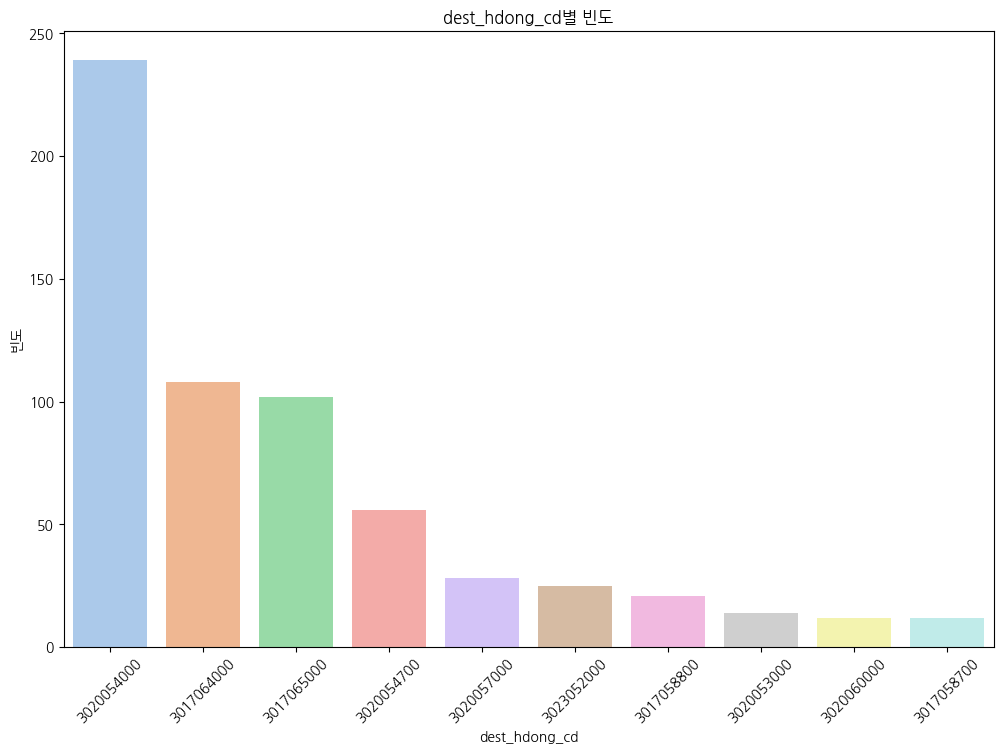

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib
# dest_hdong_cd별 빈도 계산
dest_counts = df_filtered['dest_hdong_cd'].value_counts().head(10)

# 막대 그래프로 시각화
plt.figure(figsize=(12, 8))
sns.barplot(x=dest_counts.index, y=dest_counts.values, palette="pastel")
plt.title('dest_hdong_cd별 빈도')
plt.xlabel('dest_hdong_cd')
plt.ylabel('빈도')
plt.xticks(rotation=45)
plt.show()

In [29]:
df_filtered2=df_d_date[df_d_date['od_dist_avg'] <= 20000]
df_filtered2

,origin_hdong_cd,dest_hdong_cd,date,start_time,end_time,gender,age,modal,origin_purpose,dest_purpose,od_dist_avg,od_duration_avg,od_cnts,출발지역
277642,3020055000,3014065500,20231008,16:00,16:00,0.0,1.0,지하철,기타,기타,12015.0,34.0,7.0,대전광역시 유성구 도룡동
283331,3020055000,3020060000,20231008,11:00,11:00,0.0,4.0,차량,여행,여행,11444.0,16.0,7.0,대전광역시 유성구 도룡동
284688,3020055000,3023060000,20231008,15:00,16:00,1.0,4.0,차량,여행,여행,15071.0,28.0,6.0,대전광역시 유성구 도룡동
298230,3020055000,3023052000,20231008,14:00,15:00,1.0,5.0,차량,기타,기타,3500.0,26.0,6.0,대전광역시 유성구 도룡동
299127,3020055000,3014068000,20231008,17:00,17:00,1.0,3.0,차량,기타,기타,8628.0,20.0,7.0,대전광역시 유성구 도룡동
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
166551,3020055000,3020054000,20231010,13:00,13:00,0.0,5.0,차량,여행,여행,5213.0,11.0,5.0,대전광역시 유성구 도룡동
168465,3020055000,3020054000,20231010,12:00,12:00,1.0,1.0,도보,쇼핑여가,쇼핑여가,1262.0,16.0,5.0,대전광역시 유성구 도룡동
174453,3020055000,3020054700,20231010,13:00,14:00,0.0,4.0,차량,기타,쇼핑여가,19558.0,32.0,5.0,대전광역시 유성구 도룡동
186990,3020055000,3017057500,20231010,13:00,13:00,1.0,4.0,시내버스,쇼핑여가,기타,14087.0,30.0,5.0,대전광역시 유성구 도룡동


<ipython-input-30-13a6facd510b>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dest_counts.index, y=dest_counts.values, palette="pastel")


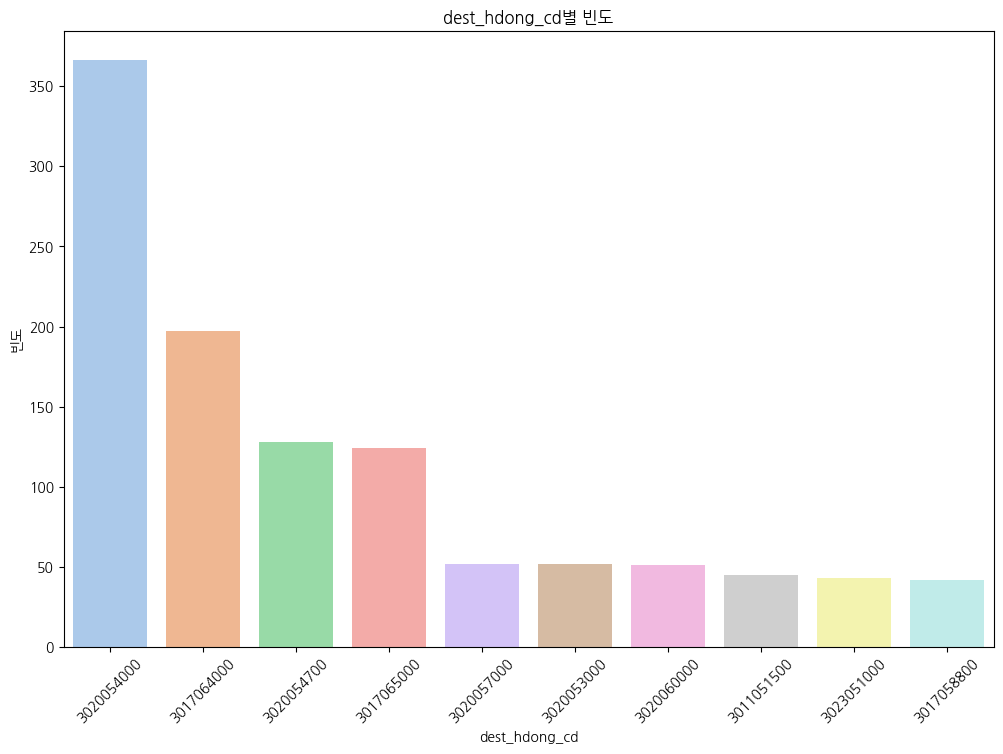

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib
# dest_hdong_cd별 빈도 계산
dest_counts = df_filtered2['dest_hdong_cd'].value_counts().head(10)

# 막대 그래프로 시각화
plt.figure(figsize=(12, 8))
sns.barplot(x=dest_counts.index, y=dest_counts.values, palette="pastel")
plt.title('dest_hdong_cd별 빈도')
plt.xlabel('dest_hdong_cd')
plt.ylabel('빈도')
plt.xticks(rotation=45)
plt.show()

<ipython-input-31-a26877e4364c>:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dest_counts.index, y=dest_counts.values, palette="pastel")


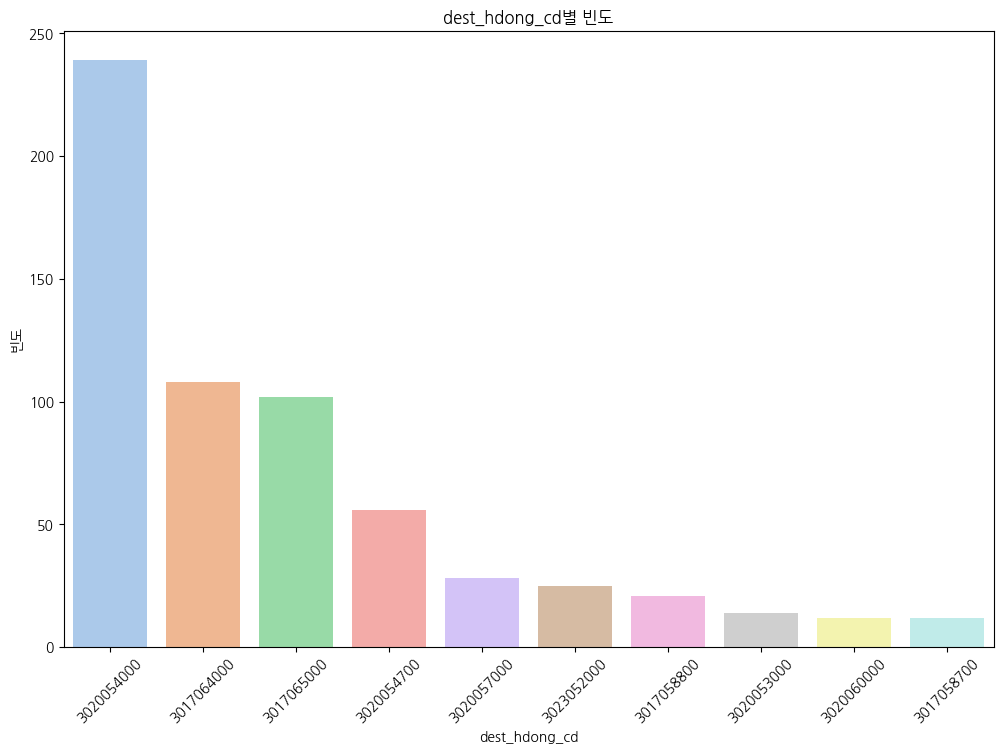

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib
# dest_hdong_cd별 빈도 계산
df_filtered3=df_d_date[df_d_date['od_dist_avg'] <= 10000]
dest_counts = df_filtered3['dest_hdong_cd'].value_counts().head(10)

# 막대 그래프로 시각화
plt.figure(figsize=(12, 8))
sns.barplot(x=dest_counts.index, y=dest_counts.values, palette="pastel")
plt.title('dest_hdong_cd별 빈도')
plt.xlabel('dest_hdong_cd')
plt.ylabel('빈도')
plt.xticks(rotation=45)
plt.show()

In [32]:
dff_d = dff[dff['출발지역'] == '대전광역시 유성구 도룡동']
dff_d

,origin_hdong_cd,dest_hdong_cd,date,start_time,end_time,gender,age,modal,origin_purpose,dest_purpose,od_dist_avg,od_duration_avg,od_cnts,출발지역
2336,3020055000,3017058800,20230901,21:00,21:00,1.0,2.0,차량,쇼핑여가,귀가,10497.0,27.0,7.0,대전광역시 유성구 도룡동
14859,3020055000,2772025000,20230901,14:00,16:00,1.0,1.0,차량,여행,귀가,228892.0,146.0,23.0,대전광역시 유성구 도룡동
16464,3020055000,3020054700,20230901,15:00,15:00,1.0,3.0,차량,쇼핑여가,귀가,24558.0,21.0,12.0,대전광역시 유성구 도룡동
23300,3020055000,4471039000,20230901,18:00,19:00,0.0,2.0,차량,기타,귀가,88922.0,56.0,15.0,대전광역시 유성구 도룡동
29781,3020055000,3020054700,20230901,12:00,12:00,0.0,4.0,차량,기타,귀가,24720.0,36.0,9.0,대전광역시 유성구 도룡동
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
699489,3020055000,3017058800,20231015,18:00,18:00,1.0,1.0,시내버스,기타,귀가,5760.0,13.0,6.0,대전광역시 유성구 도룡동
702036,3020055000,3020053000,20231015,16:00,16:00,1.0,2.0,시내버스,쇼핑여가,귀가,10269.0,32.0,5.0,대전광역시 유성구 도룡동
703813,3020055000,3017058800,20231015,16:00,17:00,0.0,4.0,차량,기타,귀가,17826.0,40.0,5.0,대전광역시 유성구 도룡동
712563,3020055000,3014057500,20231015,19:00,19:00,0.0,3.0,차량,쇼핑여가,귀가,15228.0,22.0,6.0,대전광역시 유성구 도룡동


In [33]:
dff_d_date=dff_d[(dff_d['date']>= 20231008) & (dff_d['date'] <= 20231010)]
dff_d_date

,origin_hdong_cd,dest_hdong_cd,date,start_time,end_time,gender,age,modal,origin_purpose,dest_purpose,od_dist_avg,od_duration_avg,od_cnts,출발지역
271372,3020055000,3017063000,20231008,14:00,14:00,1.0,6.0,시내버스,기타,귀가,10040.0,15.0,8.0,대전광역시 유성구 도룡동
272054,3020055000,3020054800,20231008,13:00,14:00,1.0,3.0,차량,쇼핑여가,귀가,29867.0,45.0,7.0,대전광역시 유성구 도룡동
274507,3020055000,3011053000,20231008,12:00,13:00,1.0,3.0,차량,쇼핑여가,귀가,26022.0,64.0,8.0,대전광역시 유성구 도룡동
275704,3020055000,3017064000,20231008,18:00,18:00,1.0,4.0,차량,기타,귀가,9375.0,24.0,10.0,대전광역시 유성구 도룡동
279143,3020055000,3020054700,20231008,17:00,17:00,0.0,3.0,차량,기타,귀가,11560.0,17.0,9.0,대전광역시 유성구 도룡동
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
158606,3020055000,3017051000,20231010,15:00,16:00,0.0,1.0,차량,쇼핑여가,귀가,34587.0,50.0,5.0,대전광역시 유성구 도룡동
163644,3020055000,3020054700,20231010,21:00,21:00,0.0,4.0,차량,기타,귀가,5318.0,30.0,5.0,대전광역시 유성구 도룡동
170789,3020055000,3020054700,20231010,13:00,14:00,0.0,4.0,기타,기타,귀가,11914.0,40.0,5.0,대전광역시 유성구 도룡동
172117,3020055000,4127152500,20231010,17:00,19:00,0.0,2.0,차량,여행,귀가,295261.0,130.0,5.0,대전광역시 유성구 도룡동


In [34]:
dff_d_car=dff_d_date[dff_d_date['modal']=='차량']
dff_d_car

,origin_hdong_cd,dest_hdong_cd,date,start_time,end_time,gender,age,modal,origin_purpose,dest_purpose,od_dist_avg,od_duration_avg,od_cnts,출발지역
272054,3020055000,3020054800,20231008,13:00,14:00,1.0,3.0,차량,쇼핑여가,귀가,29867.0,45.0,7.0,대전광역시 유성구 도룡동
274507,3020055000,3011053000,20231008,12:00,13:00,1.0,3.0,차량,쇼핑여가,귀가,26022.0,64.0,8.0,대전광역시 유성구 도룡동
275704,3020055000,3017064000,20231008,18:00,18:00,1.0,4.0,차량,기타,귀가,9375.0,24.0,10.0,대전광역시 유성구 도룡동
279143,3020055000,3020054700,20231008,17:00,17:00,0.0,3.0,차량,기타,귀가,11560.0,17.0,9.0,대전광역시 유성구 도룡동
281737,3020055000,3611037000,20231008,19:00,20:00,1.0,2.0,차량,쇼핑여가,귀가,106657.0,54.0,8.0,대전광역시 유성구 도룡동
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
157723,3020055000,3611054000,20231010,12:00,13:00,0.0,3.0,차량,쇼핑여가,귀가,49676.0,55.0,5.0,대전광역시 유성구 도룡동
158606,3020055000,3017051000,20231010,15:00,16:00,0.0,1.0,차량,쇼핑여가,귀가,34587.0,50.0,5.0,대전광역시 유성구 도룡동
163644,3020055000,3020054700,20231010,21:00,21:00,0.0,4.0,차량,기타,귀가,5318.0,30.0,5.0,대전광역시 유성구 도룡동
172117,3020055000,4127152500,20231010,17:00,19:00,0.0,2.0,차량,여행,귀가,295261.0,130.0,5.0,대전광역시 유성구 도룡동


In [35]:
dff_d_trans=dff_d_date[dff_d_date['modal']!='차량']
dff_d_trans

,origin_hdong_cd,dest_hdong_cd,date,start_time,end_time,gender,age,modal,origin_purpose,dest_purpose,od_dist_avg,od_duration_avg,od_cnts,출발지역
271372,3020055000,3017063000,20231008,14:00,14:00,1.0,6.0,시내버스,기타,귀가,10040.0,15.0,8.0,대전광역시 유성구 도룡동
325244,3020055000,3020054000,20231008,13:00,13:00,1.0,2.0,시내버스,쇼핑여가,귀가,6859.0,14.0,7.0,대전광역시 유성구 도룡동
331707,3020055000,3014068000,20231008,16:00,17:00,0.0,3.0,시내버스,쇼핑여가,귀가,22191.0,55.0,7.0,대전광역시 유성구 도룡동
340991,3020055000,1135070000,20231008,18:00,21:00,1.0,0.0,철도,쇼핑여가,귀가,257899.0,204.0,32.0,대전광역시 유성구 도룡동
372238,3020055000,3017055000,20231008,19:00,19:00,0.0,1.0,시내버스,쇼핑여가,귀가,13267.0,30.0,6.0,대전광역시 유성구 도룡동
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71865,3020055000,3020054000,20231010,12:00,13:00,0.0,1.0,시내버스,기타,귀가,19643.0,27.0,5.0,대전광역시 유성구 도룡동
77638,3020055000,3020054000,20231010,21:00,21:00,1.0,1.0,시내버스,쇼핑여가,귀가,8659.0,8.0,5.0,대전광역시 유성구 도룡동
138497,3020055000,3017058800,20231010,18:00,18:00,0.0,4.0,시내버스,쇼핑여가,귀가,5095.0,12.0,5.0,대전광역시 유성구 도룡동
157571,3020055000,3020054700,20231010,14:00,14:00,0.0,4.0,시내버스,기타,귀가,10842.0,16.0,5.0,대전광역시 유성구 도룡동


<ipython-input-36-94291a8d5b1c>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='end_time', y='od_cnts', data=end_time_counts, palette="pastel")


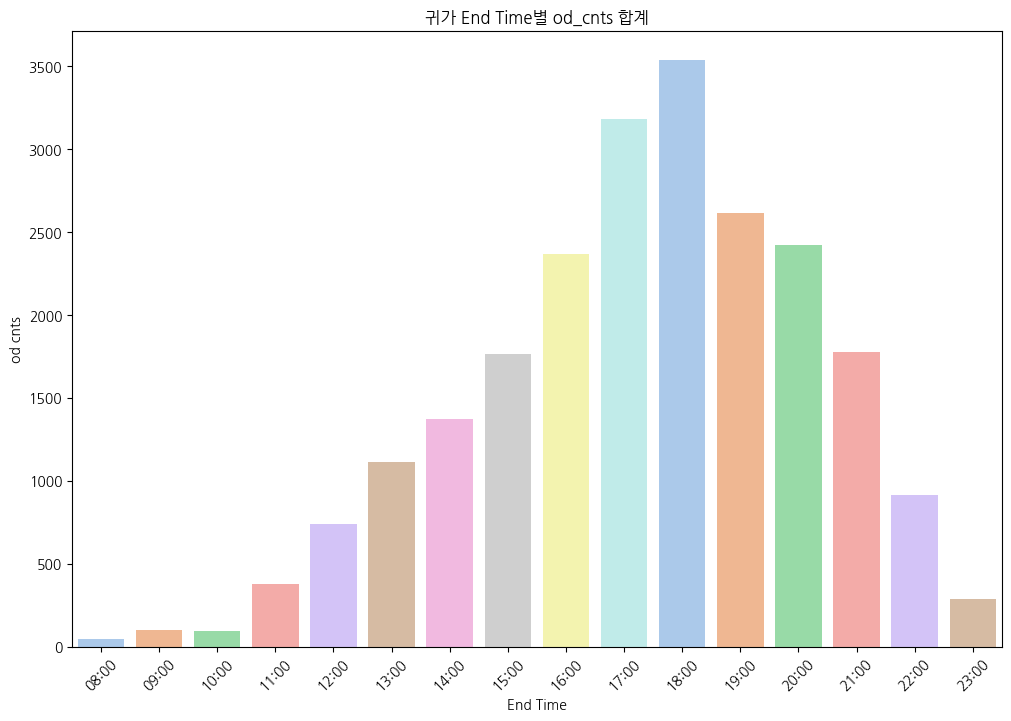

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

# end_time별로 od_cnts 합산
end_time_counts = dff_d_date.groupby('end_time')['od_cnts'].sum().reset_index()

# 상위 빈도순으로 시각화
plt.figure(figsize=(12, 8))
sns.barplot(x='end_time', y='od_cnts', data=end_time_counts, palette="pastel")
plt.title('귀가 End Time별 od_cnts 합계')
plt.xlabel('End Time')
plt.ylabel('od cnts')
plt.xticks(rotation=45)  # x축 레이블 회전
plt.show()


<ipython-input-37-029e6abdafc6>:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(x='modal', y='end_time', data=dff_d_date, jitter=True, palette="pastel")


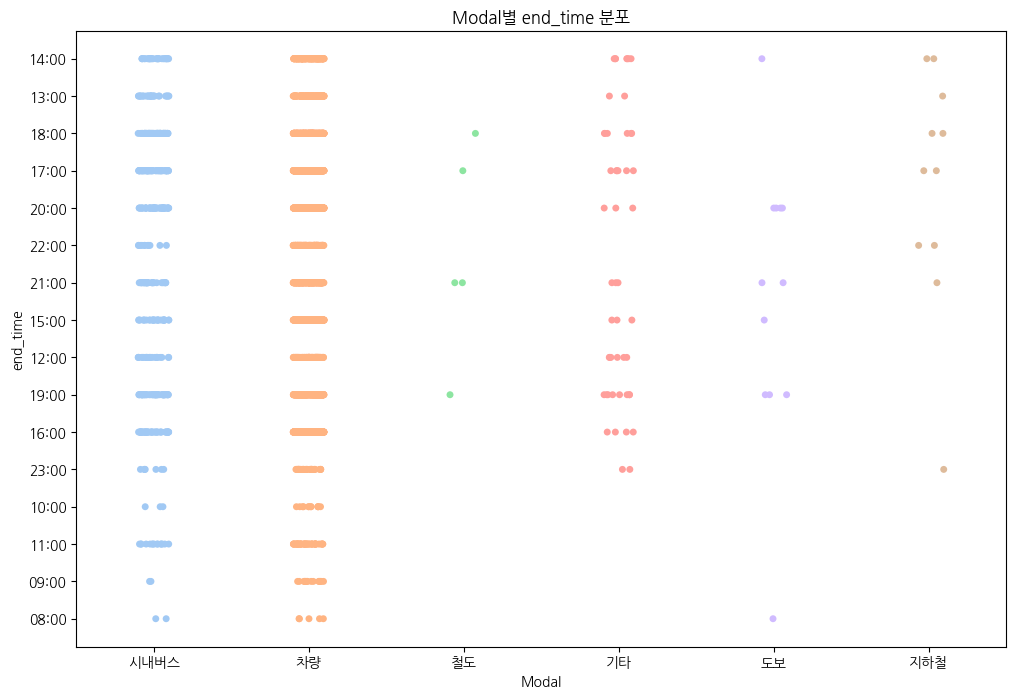

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

# 그래프 크기 설정
plt.figure(figsize=(12, 8))

# modal별 od_dist_avg 분포를 시각화
sns.stripplot(x='modal', y='end_time', data=dff_d_date, jitter=True, palette="pastel")

# 그래프 제목과 축 레이블 설정
plt.title('Modal별 end_time 분포')
plt.xlabel('Modal')
plt.ylabel('end_time')

plt.show()

<ipython-input-38-e0a57bacac4c>:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['end_time'] = pd.to_datetime(df_filtered['end_time'], format='%H:%M').dt.hour


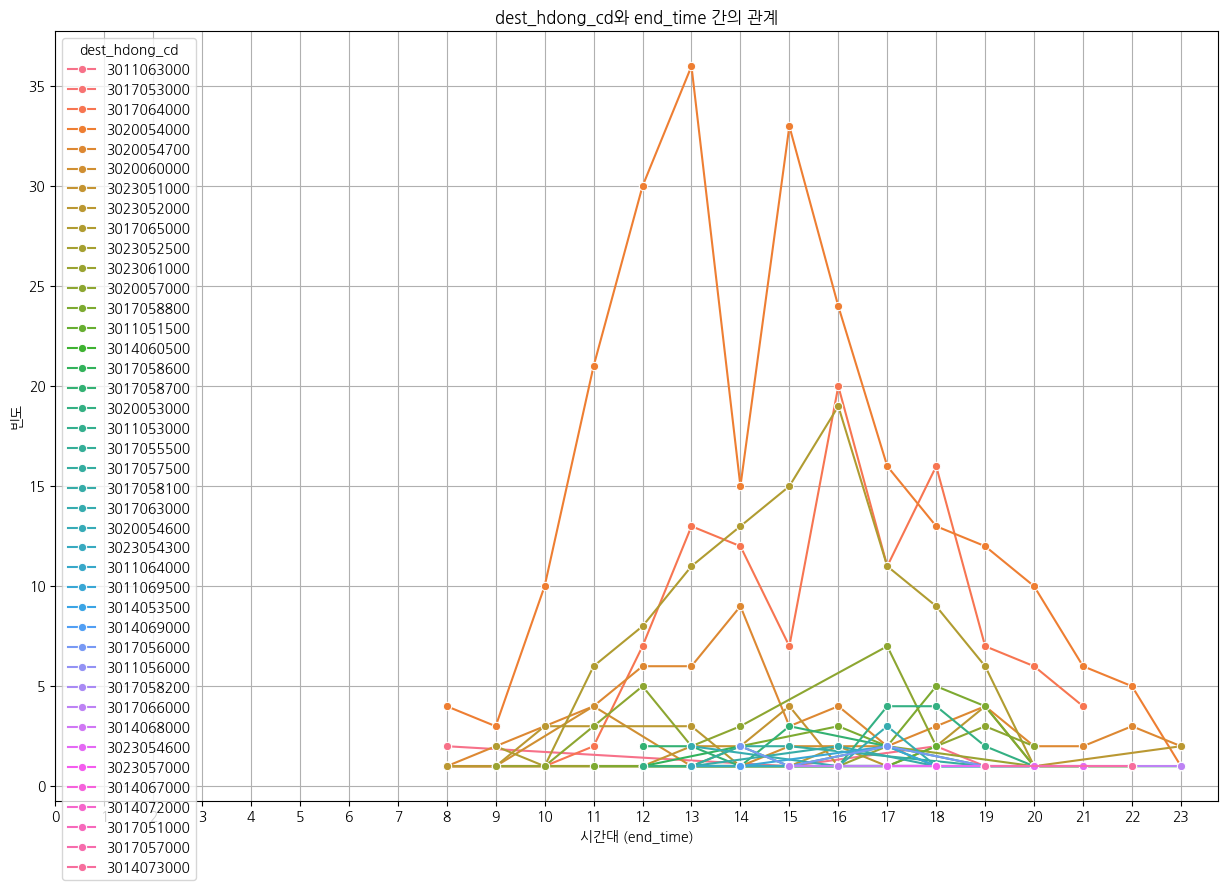

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib
import pandas as pd

# end_time을 시간 형식으로 변환 (시간 단위로)
df_filtered['end_time'] = pd.to_datetime(df_filtered['end_time'], format='%H:%M').dt.hour

# dest_hdong_cd별, end_time별 빈도 계산
dest_time_counts = df_filtered.groupby(['end_time', 'dest_hdong_cd']).size().reset_index(name='counts')

# lineplot 시각화
plt.figure(figsize=(15, 10))
sns.lineplot(data=dest_time_counts, x='end_time', y='counts', hue='dest_hdong_cd', marker='o')

# 그래프 제목과 축 레이블 설정
plt.title('dest_hdong_cd와 end_time 간의 관계')
plt.xlabel('시간대 (end_time)')
plt.ylabel('빈도')
plt.legend(title='dest_hdong_cd')
plt.xticks(range(24))  # 시간대를 0~23으로 설정
plt.grid(True)
plt.show()

# 강릉(스피드스케이트장)

In [39]:
df_GA = df[df['출발지역'] == '강릉시 포남2동']
df_GA

,origin_hdong_cd,dest_hdong_cd,date,start_time,end_time,gender,age,modal,origin_purpose,dest_purpose,od_dist_avg,od_duration_avg,od_cnts,출발지역
59107,5115057200,5115059000,20230901,15:00,15:00,0.0,1.0,차량,기타,기타,1962.0,3.0,8.0,강릉시 포남2동
65634,5115057200,5115059000,20230901,10:00,10:00,0.0,1.0,차량,기타,기타,5282.0,8.0,8.0,강릉시 포남2동
115425,5115057200,5115058000,20230901,12:00,13:00,0.0,1.0,차량,기타,기타,42160.0,39.0,28.0,강릉시 포남2동
120745,5115057200,5121051000,20230901,13:00,14:00,1.0,1.0,차량,기타,기타,251057.0,67.0,8.0,강릉시 포남2동
124332,5115057200,5115036000,20230901,11:00,12:00,1.0,3.0,차량,여행,여행,37755.0,28.0,8.0,강릉시 포남2동
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
659169,5115057200,5115064500,20231015,14:00,16:00,1.0,3.0,차량,기타,기타,266374.0,125.0,5.0,강릉시 포남2동
680028,5115057200,5115056000,20231015,17:00,17:00,0.0,4.0,차량,쇼핑여가,쇼핑여가,6612.0,12.0,6.0,강릉시 포남2동
684082,5115057200,5115066500,20231015,13:00,13:00,1.0,2.0,시내버스,쇼핑여가,쇼핑여가,11640.0,12.0,5.0,강릉시 포남2동
694731,5115057200,5115064500,20231015,17:00,18:00,1.0,3.0,차량,기타,기타,19561.0,72.0,5.0,강릉시 포남2동


In [40]:
df_ga_date=df_GA[(df_GA['date']>= 20231012) & (df_GA['date'] <= 20231015)]
df_ga_date

,origin_hdong_cd,dest_hdong_cd,date,start_time,end_time,gender,age,modal,origin_purpose,dest_purpose,od_dist_avg,od_duration_avg,od_cnts,출발지역
344812,5115057200,5183033000,20231012,13:00,14:00,1.0,5.0,차량,여행,여행,150637.0,83.0,7.0,강릉시 포남2동
350638,5115057200,5115066500,20231012,08:00,08:00,1.0,2.0,차량,기타,기타,4531.0,15.0,10.0,강릉시 포남2동
363202,5115057200,5115056000,20231012,14:00,14:00,1.0,5.0,차량,기타,기타,3511.0,10.0,11.0,강릉시 포남2동
507605,5115057200,5115052000,20231012,12:00,12:00,0.0,0.0,차량,여행,여행,21911.0,29.0,19.0,강릉시 포남2동
532159,5115057200,5115055000,20231012,18:00,18:00,1.0,4.0,차량,기타,기타,19719.0,26.0,7.0,강릉시 포남2동
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
659169,5115057200,5115064500,20231015,14:00,16:00,1.0,3.0,차량,기타,기타,266374.0,125.0,5.0,강릉시 포남2동
680028,5115057200,5115056000,20231015,17:00,17:00,0.0,4.0,차량,쇼핑여가,쇼핑여가,6612.0,12.0,6.0,강릉시 포남2동
684082,5115057200,5115066500,20231015,13:00,13:00,1.0,2.0,시내버스,쇼핑여가,쇼핑여가,11640.0,12.0,5.0,강릉시 포남2동
694731,5115057200,5115064500,20231015,17:00,18:00,1.0,3.0,차량,기타,기타,19561.0,72.0,5.0,강릉시 포남2동


In [41]:
df_filtered_GA=df_ga_date[df_ga_date['od_dist_avg'] <= 10000]
df_filtered_GA

,origin_hdong_cd,dest_hdong_cd,date,start_time,end_time,gender,age,modal,origin_purpose,dest_purpose,od_dist_avg,od_duration_avg,od_cnts,출발지역
350638,5115057200,5115066500,20231012,08:00,08:00,1.0,2.0,차량,기타,기타,4531.0,15.0,10.0,강릉시 포남2동
363202,5115057200,5115056000,20231012,14:00,14:00,1.0,5.0,차량,기타,기타,3511.0,10.0,11.0,강릉시 포남2동
712114,5115057200,5115052000,20231012,16:00,16:00,1.0,2.0,시내버스,쇼핑여가,쇼핑여가,6266.0,13.0,5.0,강릉시 포남2동
19903,5115057200,5115066500,20231012,11:00,11:00,1.0,2.0,차량,기타,기타,5547.0,27.0,5.0,강릉시 포남2동
28954,5115057200,5115066500,20231012,14:00,14:00,1.0,2.0,차량,여행,여행,9700.0,20.0,5.0,강릉시 포남2동
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
444402,5115057200,5115066500,20231015,16:00,16:00,1.0,2.0,차량,여행,여행,2691.0,2.0,5.0,강릉시 포남2동
462822,5115057200,5115064500,20231015,20:00,20:00,1.0,3.0,차량,기타,기타,6719.0,11.0,5.0,강릉시 포남2동
576475,5115057200,5115066500,20231015,18:00,18:00,1.0,2.0,차량,여행,여행,4441.0,5.0,5.0,강릉시 포남2동
630802,5115057200,5115066500,20231015,09:00,09:00,1.0,2.0,차량,여행,여행,4374.0,8.0,5.0,강릉시 포남2동


<ipython-input-42-008216571992>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dest_counts.index, y=dest_counts.values, palette="pastel")


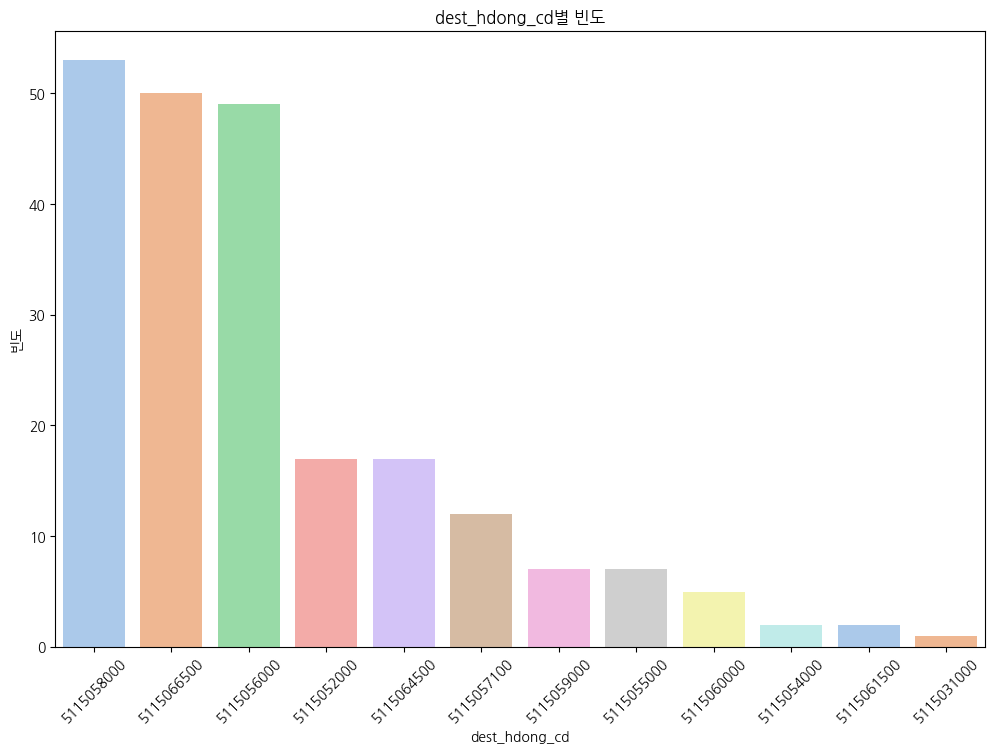

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

# dest_hdong_cd별 빈도 계산
dest_counts = df_filtered_GA['dest_hdong_cd'].value_counts()

# 막대 그래프로 시각화
plt.figure(figsize=(12, 8))
sns.barplot(x=dest_counts.index, y=dest_counts.values, palette="pastel")
plt.title('dest_hdong_cd별 빈도')
plt.xlabel('dest_hdong_cd')
plt.ylabel('빈도')
plt.xticks(rotation=45)
plt.show()

<ipython-input-43-62ae2b21f1b7>:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered_GA['end_time'] = pd.to_datetime(df_filtered_GA['end_time'], format='%H:%M').dt.hour


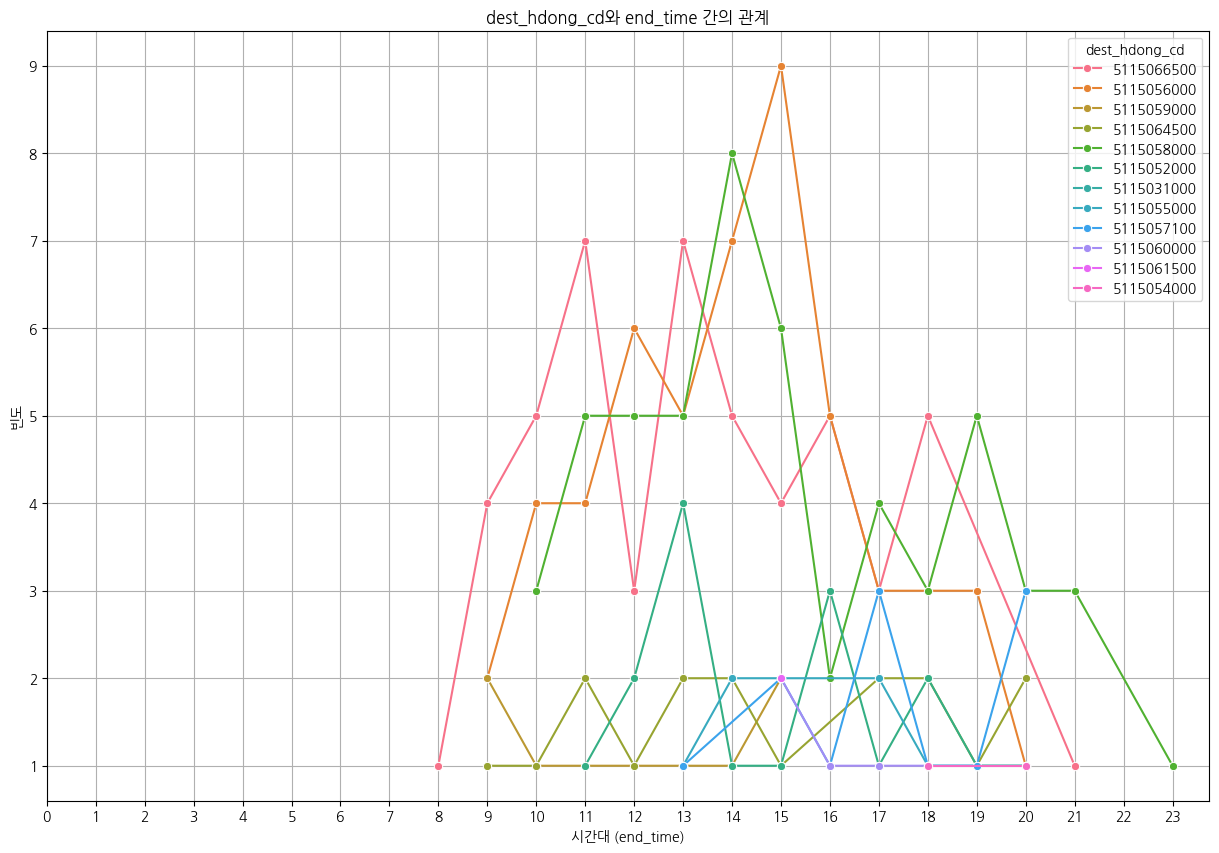

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib
import pandas as pd

# end_time을 시간 형식으로 변환 (시간 단위로)
df_filtered_GA['end_time'] = pd.to_datetime(df_filtered_GA['end_time'], format='%H:%M').dt.hour

# dest_hdong_cd별, end_time별 빈도 계산
dest_time_counts = df_filtered_GA.groupby(['end_time', 'dest_hdong_cd']).size().reset_index(name='counts')

# lineplot 시각화
plt.figure(figsize=(15, 10))
sns.lineplot(data=dest_time_counts, x='end_time', y='counts', hue='dest_hdong_cd', marker='o')

# 그래프 제목과 축 레이블 설정
plt.title('dest_hdong_cd와 end_time 간의 관계')
plt.xlabel('시간대 (end_time)')
plt.ylabel('빈도')
plt.legend(title='dest_hdong_cd')
plt.xticks(range(24))  # 시간대를 0~23으로 설정
plt.grid(True)
plt.show()

In [44]:
dff_GA=dff[(dff['출발지역'])=='강릉시 포남2동']
dff_GA

,origin_hdong_cd,dest_hdong_cd,date,start_time,end_time,gender,age,modal,origin_purpose,dest_purpose,od_dist_avg,od_duration_avg,od_cnts,출발지역
5575,5115057200,5115064500,20230901,18:00,18:00,1.0,0.0,시내버스,기타,귀가,33727.0,24.0,14.0,강릉시 포남2동
58526,5115057200,5115059000,20230901,17:00,18:00,0.0,0.0,기타,쇼핑여가,귀가,8065.0,45.0,16.0,강릉시 포남2동
124434,5115057200,5115055000,20230901,11:00,12:00,0.0,0.0,차량,쇼핑여가,귀가,4106.0,22.0,21.0,강릉시 포남2동
179091,5115057200,5115058000,20230901,16:00,16:00,0.0,0.0,차량,기타,귀가,8096.0,5.0,24.0,강릉시 포남2동
324124,5115057200,5119052500,20230901,18:00,19:00,0.0,3.0,차량,쇼핑여가,귀가,308767.0,108.0,6.0,강릉시 포남2동
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
585189,5115057200,5115059000,20231015,10:00,10:00,1.0,5.0,차량,쇼핑여가,귀가,3692.0,9.0,5.0,강릉시 포남2동
650269,5115057200,5115055000,20231015,18:00,19:00,1.0,1.0,차량,쇼핑여가,귀가,53824.0,46.0,5.0,강릉시 포남2동
668901,5115057200,5115055000,20231015,19:00,19:00,1.0,1.0,시내버스,기타,귀가,24002.0,14.0,5.0,강릉시 포남2동
680510,5115057200,5115059000,20231015,12:00,13:00,1.0,1.0,차량,기타,귀가,23789.0,40.0,5.0,강릉시 포남2동


In [45]:
dff_ga_date=dff_GA[(dff_GA['date']>= 20231012) & (dff_GA['date'] <= 20231015)]
dff_ga_date

,origin_hdong_cd,dest_hdong_cd,date,start_time,end_time,gender,age,modal,origin_purpose,dest_purpose,od_dist_avg,od_duration_avg,od_cnts,출발지역
375263,5115057200,5115059000,20231012,15:00,15:00,1.0,0.0,차량,기타,귀가,12086.0,11.0,10.0,강릉시 포남2동
447715,5115057200,5115055000,20231012,16:00,16:00,1.0,0.0,차량,기타,귀가,2344.0,28.0,15.0,강릉시 포남2동
551170,5115057200,5115060000,20231012,14:00,15:00,0.0,2.0,차량,기타,귀가,27032.0,61.0,6.0,강릉시 포남2동
569485,5115057200,5115058000,20231012,17:00,18:00,0.0,3.0,차량,쇼핑여가,귀가,61430.0,61.0,5.0,강릉시 포남2동
589304,5115057200,5115064500,20231012,12:00,12:00,1.0,3.0,차량,기타,귀가,6963.0,11.0,5.0,강릉시 포남2동
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
585189,5115057200,5115059000,20231015,10:00,10:00,1.0,5.0,차량,쇼핑여가,귀가,3692.0,9.0,5.0,강릉시 포남2동
650269,5115057200,5115055000,20231015,18:00,19:00,1.0,1.0,차량,쇼핑여가,귀가,53824.0,46.0,5.0,강릉시 포남2동
668901,5115057200,5115055000,20231015,19:00,19:00,1.0,1.0,시내버스,기타,귀가,24002.0,14.0,5.0,강릉시 포남2동
680510,5115057200,5115059000,20231015,12:00,13:00,1.0,1.0,차량,기타,귀가,23789.0,40.0,5.0,강릉시 포남2동


<ipython-input-46-0f9df9783b97>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='end_time', y='od_cnts', data=end_time_counts, palette="pastel")


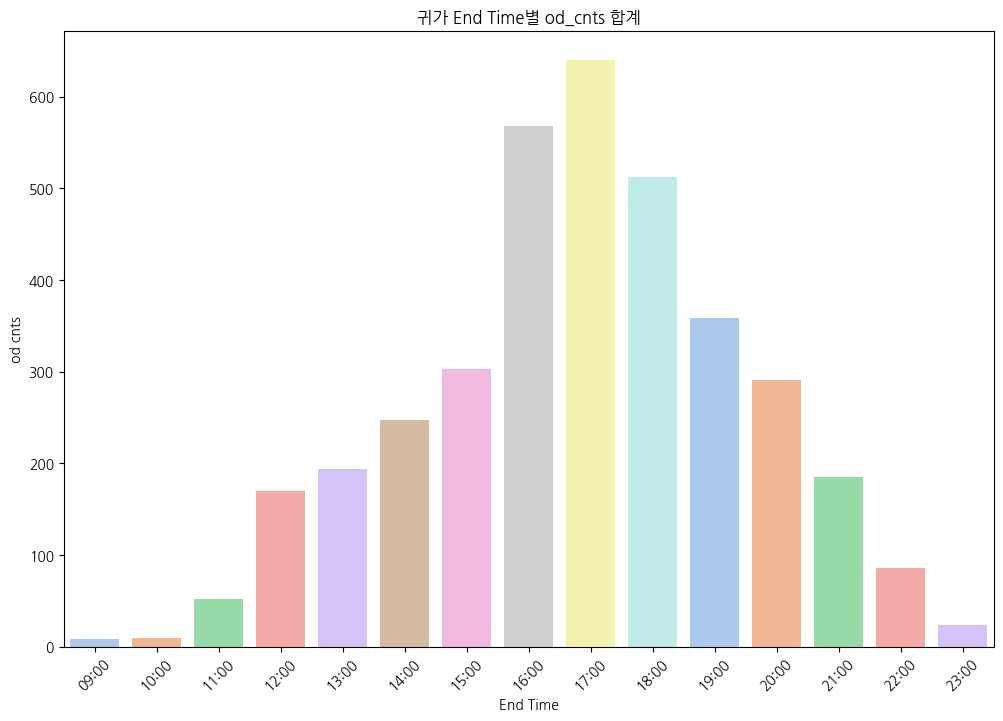

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

# end_time별로 od_cnts 합산
end_time_counts = dff_ga_date.groupby('end_time')['od_cnts'].sum().reset_index()

# 상위 빈도순으로 시각화
plt.figure(figsize=(12, 8))
sns.barplot(x='end_time', y='od_cnts', data=end_time_counts, palette="pastel")
plt.title('귀가 End Time별 od_cnts 합계')
plt.xlabel('End Time')
plt.ylabel('od cnts')
plt.xticks(rotation=45)  # x축 레이블 회전
plt.show()

<ipython-input-47-ac318914febb>:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(x='modal', y='end_time', data=dff_ga_date, jitter=True, palette="pastel")


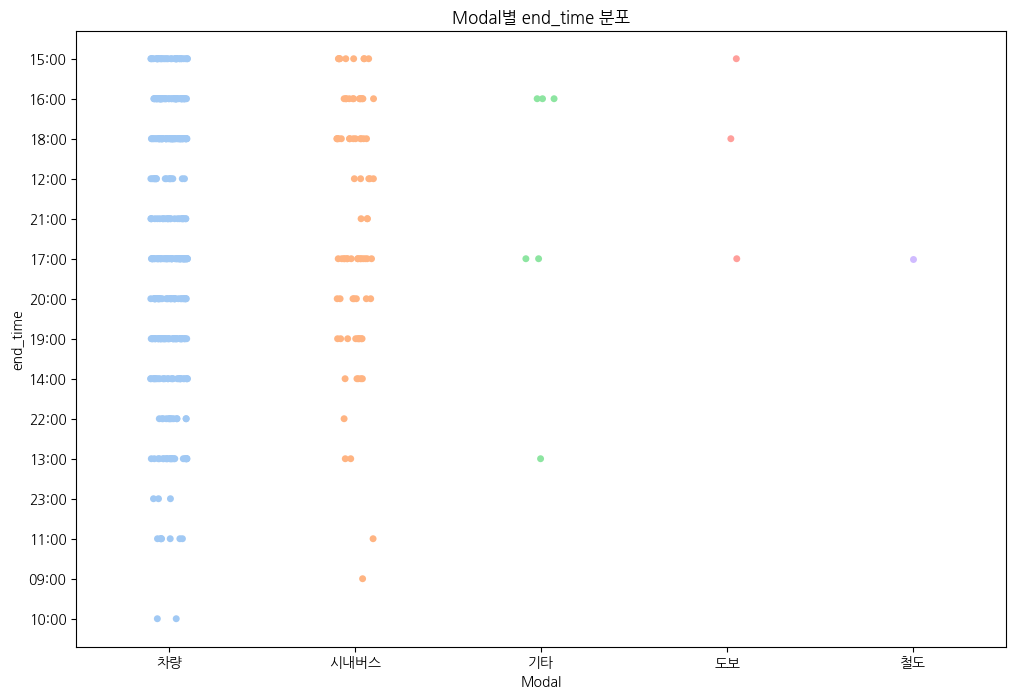

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

# 그래프 크기 설정
plt.figure(figsize=(12, 8))

# modal별 od_dist_avg 분포를 시각화
sns.stripplot(x='modal', y='end_time', data=dff_ga_date, jitter=True, palette="pastel")

# 그래프 제목과 축 레이블 설정
plt.title('Modal별 end_time 분포')
plt.xlabel('Modal')
plt.ylabel('end_time')

plt.show()

# 강릉(경포호수공원)

In [48]:
df_GB = df[df['출발지역'] == '강릉시 초당동' ]
df_GB

,origin_hdong_cd,dest_hdong_cd,date,start_time,end_time,gender,age,modal,origin_purpose,dest_purpose,od_dist_avg,od_duration_avg,od_cnts,출발지역
3302,5115058000,5115066500,20230901,19:00,19:00,1.0,1.0,차량,여행,여행,10232.0,7.0,8.0,강릉시 초당동
6500,5115058000,5115025000,20230901,13:00,15:00,1.0,5.0,차량,여행,여행,120666.0,114.0,9.0,강릉시 초당동
46933,5115058000,5115066500,20230901,19:00,21:00,1.0,2.0,차량,여행,여행,100035.0,99.0,14.0,강릉시 초당동
80944,5115058000,5115066500,20230901,16:00,16:00,1.0,2.0,차량,여행,여행,17613.0,12.0,10.0,강릉시 초당동
81560,5115058000,5115066500,20230901,10:00,13:00,1.0,2.0,차량,여행,여행,116246.0,161.0,10.0,강릉시 초당동
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
653204,5115058000,5115066500,20231015,20:00,20:00,1.0,2.0,차량,쇼핑여가,기타,8393.0,7.0,5.0,강릉시 초당동
665885,5115058000,5115064500,20231015,12:00,13:00,1.0,3.0,기타,여행,여행,18492.0,69.0,5.0,강릉시 초당동
685147,5115058000,5115066500,20231015,12:00,13:00,1.0,2.0,차량,기타,기타,44245.0,78.0,5.0,강릉시 초당동
703637,5115058000,5115025000,20231015,14:00,15:00,1.0,7.0,차량,여행,여행,66479.0,67.0,5.0,강릉시 초당동


In [49]:
df_gb_date=df_GB[(df_GB['date']>= 20231012) & (df_GB['date'] <= 20231015)]
df_gb_date

,origin_hdong_cd,dest_hdong_cd,date,start_time,end_time,gender,age,modal,origin_purpose,dest_purpose,od_dist_avg,od_duration_avg,od_cnts,출발지역
303173,5115058000,5115066500,20231012,18:00,19:00,1.0,1.0,차량,여행,여행,40133.0,53.0,8.0,강릉시 초당동
318587,5115058000,5115066500,20231012,12:00,13:00,1.0,2.0,차량,여행,여행,22049.0,51.0,10.0,강릉시 초당동
322324,5115058000,5115066500,20231012,15:00,16:00,1.0,2.0,차량,여행,여행,19492.0,25.0,14.0,강릉시 초당동
330038,5115058000,5115066500,20231012,22:00,22:00,1.0,2.0,차량,여행,여행,12476.0,28.0,10.0,강릉시 초당동
332836,5115058000,5115034000,20231012,12:00,14:00,0.0,3.0,차량,여행,여행,131039.0,94.0,9.0,강릉시 초당동
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
653204,5115058000,5115066500,20231015,20:00,20:00,1.0,2.0,차량,쇼핑여가,기타,8393.0,7.0,5.0,강릉시 초당동
665885,5115058000,5115064500,20231015,12:00,13:00,1.0,3.0,기타,여행,여행,18492.0,69.0,5.0,강릉시 초당동
685147,5115058000,5115066500,20231015,12:00,13:00,1.0,2.0,차량,기타,기타,44245.0,78.0,5.0,강릉시 초당동
703637,5115058000,5115025000,20231015,14:00,15:00,1.0,7.0,차량,여행,여행,66479.0,67.0,5.0,강릉시 초당동


In [50]:
df_filtered_GB=df_gb_date[df_gb_date['od_dist_avg'] <= 10000]
df_filtered_GB

,origin_hdong_cd,dest_hdong_cd,date,start_time,end_time,gender,age,modal,origin_purpose,dest_purpose,od_dist_avg,od_duration_avg,od_cnts,출발지역
336162,5115058000,5115066500,20231012,13:00,13:00,0.0,2.0,차량,여행,여행,4970.0,17.0,13.0,강릉시 초당동
408107,5115058000,5115066500,20231012,10:00,10:00,1.0,2.0,기타,여행,여행,1041.0,7.0,10.0,강릉시 초당동
431408,5115058000,5115054000,20231012,13:00,13:00,1.0,0.0,시내버스,여행,여행,7811.0,12.0,12.0,강릉시 초당동
471698,5115058000,5115066500,20231012,21:00,21:00,1.0,2.0,차량,여행,여행,5212.0,9.0,14.0,강릉시 초당동
483484,5115058000,5115057200,20231012,13:00,14:00,0.0,0.0,도보,여행,여행,3711.0,21.0,35.0,강릉시 초당동
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
625258,5115058000,5115064500,20231015,15:00,15:00,1.0,4.0,차량,여행,여행,4216.0,10.0,5.0,강릉시 초당동
639164,5115058000,5115066500,20231015,14:00,15:00,1.0,2.0,차량,쇼핑여가,쇼핑여가,5129.0,12.0,5.0,강릉시 초당동
646316,5115058000,5115057200,20231015,22:00,22:00,0.0,2.0,차량,여행,여행,8498.0,16.0,5.0,강릉시 초당동
653204,5115058000,5115066500,20231015,20:00,20:00,1.0,2.0,차량,쇼핑여가,기타,8393.0,7.0,5.0,강릉시 초당동


<ipython-input-51-83b04b941135>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dest_counts.index, y=dest_counts.values, palette="pastel")


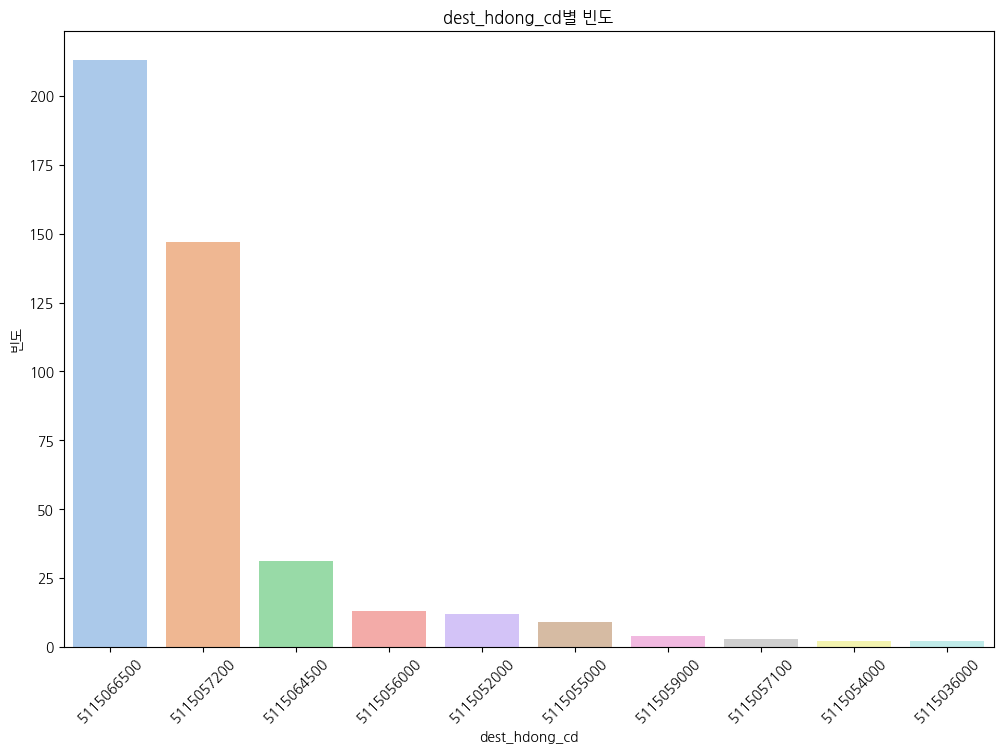

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

# dest_hdong_cd별 빈도 계산
dest_counts = df_filtered_GB['dest_hdong_cd'].value_counts()

# 막대 그래프로 시각화
plt.figure(figsize=(12, 8))
sns.barplot(x=dest_counts.index, y=dest_counts.values, palette="pastel")
plt.title('dest_hdong_cd별 빈도')
plt.xlabel('dest_hdong_cd')
plt.ylabel('빈도')
plt.xticks(rotation=45)
plt.show()

<ipython-input-52-cdb22f25383a>:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered_GB['end_time'] = pd.to_datetime(df_filtered_GB['end_time'], format='%H:%M').dt.hour


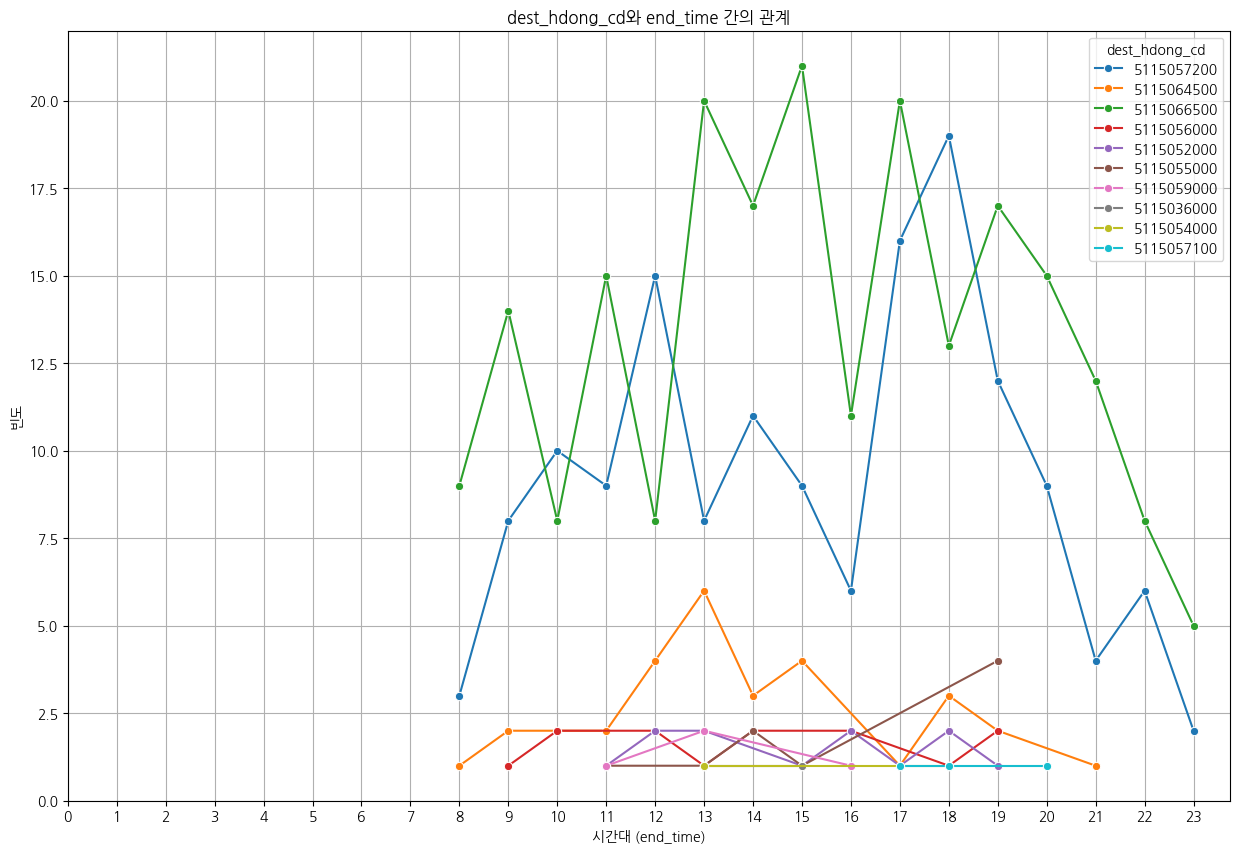

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib
import pandas as pd

# end_time을 시간 형식으로 변환 (시간 단위로)
df_filtered_GB['end_time'] = pd.to_datetime(df_filtered_GB['end_time'], format='%H:%M').dt.hour

# dest_hdong_cd별, end_time별 빈도 계산
dest_time_counts = df_filtered_GB.groupby(['end_time', 'dest_hdong_cd']).size().reset_index(name='counts')

# lineplot 시각화
plt.figure(figsize=(15, 10))
sns.lineplot(data=dest_time_counts, x='end_time', y='counts', hue='dest_hdong_cd', marker='o')

# 그래프 제목과 축 레이블 설정
plt.title('dest_hdong_cd와 end_time 간의 관계')
plt.xlabel('시간대 (end_time)')
plt.ylabel('빈도')
plt.legend(title='dest_hdong_cd')
plt.xticks(range(24))  # 시간대를 0~23으로 설정
plt.grid(True)
plt.show()

In [53]:
dff_GB = dff[dff['출발지역'] == '강릉시 초당동' ]
dff_GB

,origin_hdong_cd,dest_hdong_cd,date,start_time,end_time,gender,age,modal,origin_purpose,dest_purpose,od_dist_avg,od_duration_avg,od_cnts,출발지역
148421,5115058000,5115064500,20230901,16:00,17:00,0.0,1.0,시내버스,기타,귀가,22541.0,44.0,10.0,강릉시 초당동
224977,5115058000,5115064500,20230901,16:00,16:00,0.0,1.0,차량,기타,귀가,28168.0,22.0,14.0,강릉시 초당동
278657,5115058000,5115066500,20230901,13:00,13:00,0.0,2.0,차량,기타,귀가,10765.0,11.0,9.0,강릉시 초당동
318902,5115058000,5115057200,20230901,14:00,14:00,0.0,2.0,시내버스,기타,귀가,11094.0,11.0,5.0,강릉시 초당동
325407,5115058000,5115057200,20230901,15:00,15:00,1.0,7.0,차량,기타,귀가,5803.0,10.0,5.0,강릉시 초당동
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
668891,5115058000,5115066500,20231015,17:00,18:00,1.0,2.0,차량,쇼핑여가,귀가,59388.0,67.0,5.0,강릉시 초당동
674618,5115058000,5115055000,20231015,12:00,12:00,1.0,1.0,차량,기타,귀가,19041.0,36.0,5.0,강릉시 초당동
675131,5115058000,5115064500,20231015,16:00,17:00,1.0,3.0,차량,쇼핑여가,귀가,12382.0,18.0,5.0,강릉시 초당동
691071,5115058000,1156058500,20231015,13:00,19:00,1.0,2.0,차량,여행,귀가,483037.0,378.0,5.0,강릉시 초당동


In [54]:
dff_gb_date=dff_GB[(dff_GB['date']>= 20231012) & (dff_GB['date'] <= 20231015)]
dff_gb_date

,origin_hdong_cd,dest_hdong_cd,date,start_time,end_time,gender,age,modal,origin_purpose,dest_purpose,od_dist_avg,od_duration_avg,od_cnts,출발지역
266880,5115058000,5115057100,20231012,16:00,16:00,0.0,1.0,차량,기타,귀가,35548.0,34.0,11.0,강릉시 초당동
280894,5115058000,5115055000,20231012,21:00,21:00,1.0,4.0,시내버스,기타,귀가,13777.0,15.0,7.0,강릉시 초당동
286187,5115058000,5115059000,20231012,16:00,16:00,0.0,1.0,시내버스,기타,귀가,45682.0,21.0,11.0,강릉시 초당동
353333,5115058000,5115064500,20231012,18:00,19:00,0.0,1.0,차량,기타,귀가,48186.0,49.0,7.0,강릉시 초당동
404457,5115058000,5115061500,20231012,16:00,17:00,0.0,1.0,차량,기타,귀가,33156.0,54.0,13.0,강릉시 초당동
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
668891,5115058000,5115066500,20231015,17:00,18:00,1.0,2.0,차량,쇼핑여가,귀가,59388.0,67.0,5.0,강릉시 초당동
674618,5115058000,5115055000,20231015,12:00,12:00,1.0,1.0,차량,기타,귀가,19041.0,36.0,5.0,강릉시 초당동
675131,5115058000,5115064500,20231015,16:00,17:00,1.0,3.0,차량,쇼핑여가,귀가,12382.0,18.0,5.0,강릉시 초당동
691071,5115058000,1156058500,20231015,13:00,19:00,1.0,2.0,차량,여행,귀가,483037.0,378.0,5.0,강릉시 초당동


<ipython-input-55-de3e730fdb6d>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='end_time', y='od_cnts', data=end_time_counts, palette="pastel")


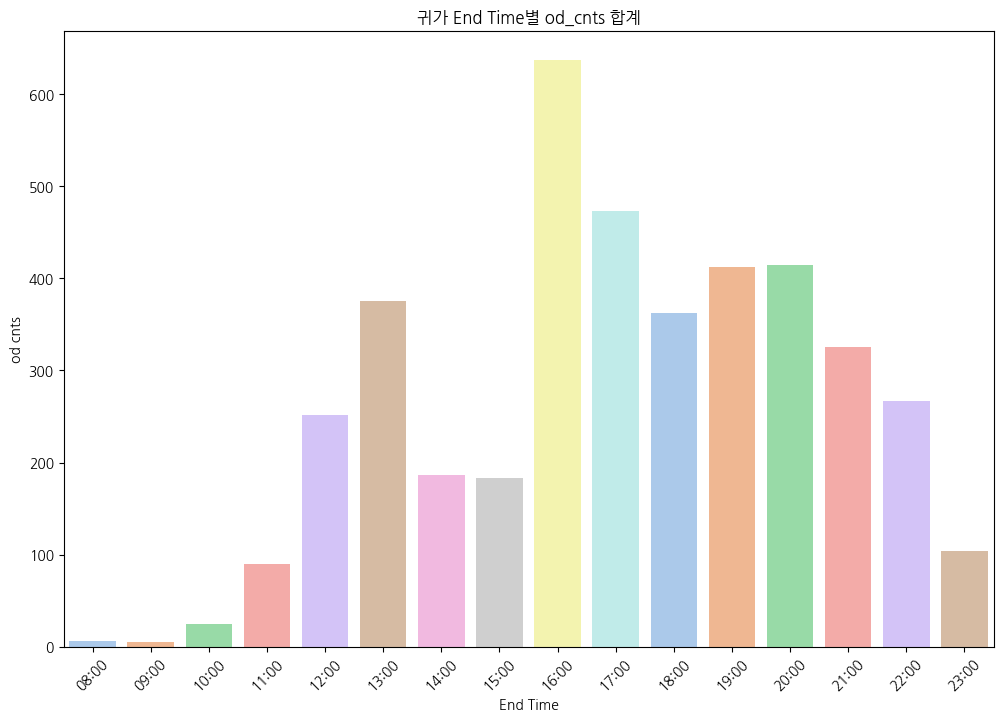

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

# end_time별로 od_cnts 합산
end_time_counts = dff_gb_date.groupby('end_time')['od_cnts'].sum().reset_index()

# 상위 빈도순으로 시각화
plt.figure(figsize=(12, 8))
sns.barplot(x='end_time', y='od_cnts', data=end_time_counts, palette="pastel")
plt.title('귀가 End Time별 od_cnts 합계')
plt.xlabel('End Time')
plt.ylabel('od cnts')
plt.xticks(rotation=45)  # x축 레이블 회전
plt.show()

<ipython-input-56-f9432c0edf53>:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(x='modal', y='end_time', data=dff_gb_date, jitter=True, palette="pastel")


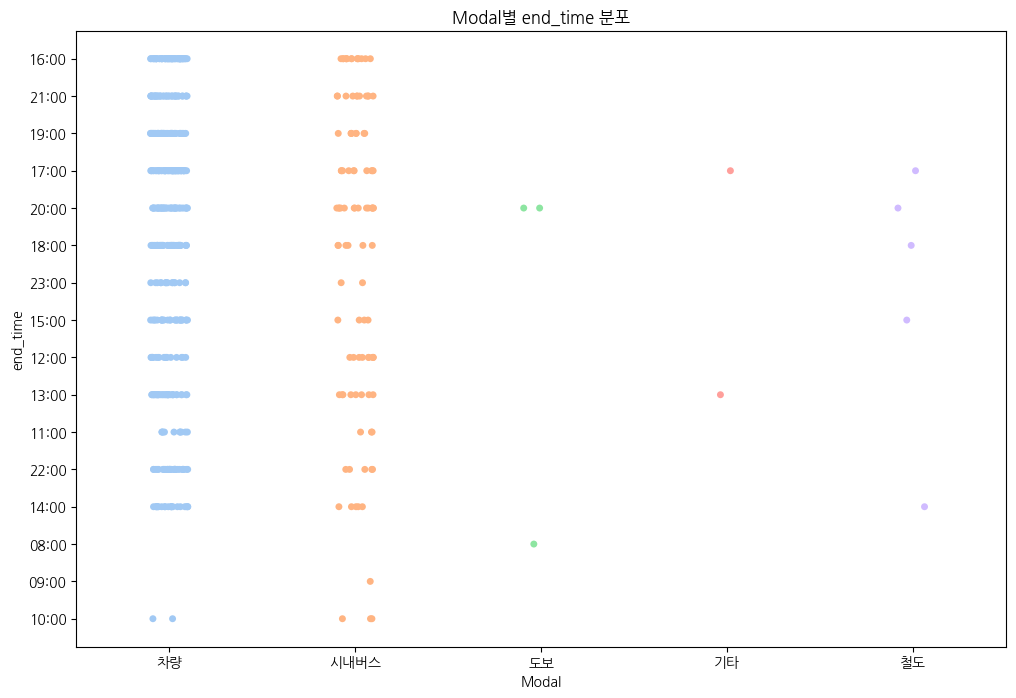

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

# 그래프 크기 설정
plt.figure(figsize=(12, 8))

# modal별 od_dist_avg 분포를 시각화
sns.stripplot(x='modal', y='end_time', data=dff_gb_date, jitter=True, palette="pastel")

# 그래프 제목과 축 레이블 설정
plt.title('Modal별 end_time 분포')
plt.xlabel('Modal')
plt.ylabel('end_time')

plt.show()

# 임실

In [57]:
df_I = df[df['출발지역'] == '임실 성수면']
df_I

,origin_hdong_cd,dest_hdong_cd,date,start_time,end_time,gender,age,modal,origin_purpose,dest_purpose,od_dist_avg,od_duration_avg,od_cnts,출발지역
425467,4575034000,4575035500,20230901,14:00,14:00,0.0,3.0,기타,기타,기타,355.0,1.0,5.0,임실 성수면
688918,4575034000,4617032000,20230901,13:00,15:00,0.0,3.0,차량,기타,기타,216279.0,141.0,5.0,임실 성수면
296995,4575034000,4574031000,20230901,17:00,17:00,0.0,3.0,차량,여행,여행,32615.0,15.0,7.0,임실 성수면
388078,4575034000,4575032000,20230901,12:00,14:00,0.0,4.0,시내버스,여행,쇼핑여가,55430.0,118.0,6.0,임실 성수면
618111,4575034000,4575035500,20230901,12:00,12:00,0.0,3.0,차량,기타,기타,4229.0,19.0,5.0,임실 성수면
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
470254,4575034000,2920051500,20231015,14:00,16:00,1.0,6.0,차량,여행,여행,278989.0,114.0,5.0,임실 성수면
571868,4575034000,4575032000,20231015,12:00,13:00,0.0,4.0,차량,여행,여행,49934.0,56.0,6.0,임실 성수면
687251,4575034000,4577034000,20231015,15:00,16:00,1.0,2.0,차량,여행,여행,71232.0,30.0,5.0,임실 성수면
689935,4575034000,4575032000,20231015,12:00,12:00,1.0,4.0,차량,기타,기타,85154.0,45.0,6.0,임실 성수면


In [58]:
df_I_date=df_I[(df_I['date']>= 20231006) & (df_I['date'] <= 20231009)]
df_I_date

,origin_hdong_cd,dest_hdong_cd,date,start_time,end_time,gender,age,modal,origin_purpose,dest_purpose,od_dist_avg,od_duration_avg,od_cnts,출발지역
190863,4575034000,4575038000,20231006,14:00,14:00,1.0,5.0,차량,기타,기타,13323.0,21.0,8.0,임실 성수면
258841,4575034000,4511357000,20231006,20:00,22:00,1.0,0.0,차량,기타,기타,177516.0,117.0,11.0,임실 성수면
279841,4575034000,4511357000,20231006,17:00,18:00,0.0,2.0,차량,기타,기타,276939.0,86.0,7.0,임실 성수면
287056,4575034000,4374036000,20231006,10:00,12:00,0.0,4.0,차량,기타,여행,121676.0,122.0,9.0,임실 성수면
292187,4575034000,4575032000,20231006,11:00,13:00,1.0,6.0,차량,여행,여행,116735.0,116.0,7.0,임실 성수면
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
137275,4575034000,4575025000,20231009,13:00,14:00,0.0,3.0,차량,여행,여행,9199.0,33.0,6.0,임실 성수면
163379,4575034000,4571034000,20231009,13:00,15:00,1.0,4.0,차량,기타,쇼핑여가,140387.0,98.0,5.0,임실 성수면
176815,4575034000,4521045000,20231009,15:00,16:00,1.0,4.0,차량,기타,쇼핑여가,165954.0,64.0,5.0,임실 성수면
187041,4575034000,4514064600,20231009,15:00,18:00,0.0,1.0,차량,기타,기타,195103.0,149.0,5.0,임실 성수면


In [59]:
df_filtered_I=df_I_date[df_I_date['od_dist_avg'] <= 10000]
df_filtered_I

,origin_hdong_cd,dest_hdong_cd,date,start_time,end_time,gender,age,modal,origin_purpose,dest_purpose,od_dist_avg,od_duration_avg,od_cnts,출발지역
319264,4575034000,4575025000,20231006,12:00,12:00,1.0,6.0,차량,기타,기타,3221.0,5.0,7.0,임실 성수면
548166,4575034000,4575025000,20231006,17:00,17:00,1.0,6.0,차량,여행,여행,6660.0,4.0,6.0,임실 성수면
609653,4575034000,4575025000,20231006,14:00,14:00,0.0,3.0,차량,기타,기타,2323.0,6.0,6.0,임실 성수면
49106,4575034000,4575025000,20231006,13:00,13:00,1.0,6.0,차량,기타,기타,5412.0,5.0,7.0,임실 성수면
642755,4575034000,4575025000,20231006,13:00,13:00,1.0,3.0,차량,기타,기타,8896.0,12.0,7.0,임실 성수면
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
623019,4575034000,4575025000,20231009,12:00,12:00,1.0,0.0,기타,기타,기타,752.0,10.0,15.0,임실 성수면
631595,4575034000,4575025000,20231009,13:00,15:00,1.0,0.0,차량,기타,기타,7887.0,78.0,15.0,임실 성수면
680113,4575034000,4575025000,20231009,16:00,16:00,1.0,7.0,기타,여행,여행,1186.0,6.0,6.0,임실 성수면
130977,4575034000,4575025000,20231009,17:00,17:00,0.0,4.0,기타,기타,기타,390.0,2.0,5.0,임실 성수면


<ipython-input-60-69a7a5b3325a>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dest_counts.index, y=dest_counts.values, palette="pastel")


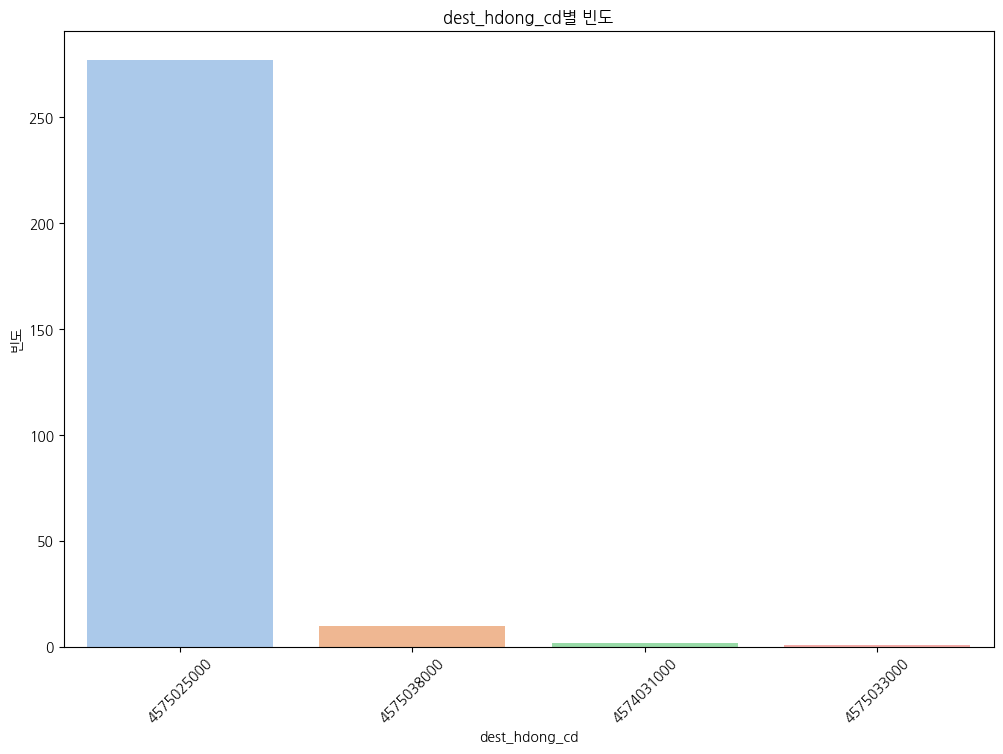

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns

# dest_hdong_cd별 빈도 계산
dest_counts = df_filtered_I['dest_hdong_cd'].value_counts().head(10)

# 막대 그래프로 시각화
plt.figure(figsize=(12, 8))
sns.barplot(x=dest_counts.index, y=dest_counts.values, palette="pastel")
plt.title('dest_hdong_cd별 빈도')
plt.xlabel('dest_hdong_cd')
plt.ylabel('빈도')
plt.xticks(rotation=45)
plt.show()

In [61]:
dff_I = dff[dff['출발지역'] == '임실 성수면']
dff_I

,origin_hdong_cd,dest_hdong_cd,date,start_time,end_time,gender,age,modal,origin_purpose,dest_purpose,od_dist_avg,od_duration_avg,od_cnts,출발지역
401602,4575034000,4511359000,20230901,11:00,12:00,1.0,1.0,차량,기타,귀가,33562.0,44.0,6.0,임실 성수면
107713,4575034000,4511170100,20230901,09:00,10:00,1.0,5.0,차량,기타,귀가,56541.0,64.0,7.0,임실 성수면
108491,4575034000,4511170100,20230901,17:00,18:00,0.0,3.0,차량,기타,귀가,50632.0,43.0,8.0,임실 성수면
121918,4575034000,4511165000,20230901,21:00,22:00,0.0,3.0,차량,기타,귀가,54482.0,56.0,9.0,임실 성수면
220603,4575034000,4511170100,20230901,16:00,17:00,0.0,3.0,차량,기타,귀가,72910.0,64.0,8.0,임실 성수면
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
498227,4575034000,4511160500,20231015,13:00,14:00,0.0,1.0,차량,기타,귀가,56985.0,65.0,5.0,임실 성수면
579152,4575034000,4514059500,20231015,14:00,15:00,0.0,1.0,차량,기타,귀가,50484.0,70.0,6.0,임실 성수면
604216,4575034000,2920055000,20231015,18:00,19:00,1.0,3.0,차량,여행,귀가,144574.0,87.0,5.0,임실 성수면
649349,4575034000,4373025000,20231015,15:00,18:00,1.0,3.0,차량,여행,귀가,177750.0,127.0,5.0,임실 성수면


In [62]:
dff_I_date=dff_I[(dff_I['date']>= 20231006) & (dff_I['date'] <= 20231009)]
dff_I_date

,origin_hdong_cd,dest_hdong_cd,date,start_time,end_time,gender,age,modal,origin_purpose,dest_purpose,od_dist_avg,od_duration_avg,od_cnts,출발지역
202038,4575034000,4575035500,20231006,18:00,19:00,1.0,2.0,차량,기타,귀가,66038.0,49.0,7.0,임실 성수면
342062,4575034000,4571032000,20231006,20:00,21:00,0.0,3.0,차량,기타,귀가,97233.0,99.0,8.0,임실 성수면
373647,4575034000,4575025000,20231006,21:00,21:00,0.0,0.0,차량,기타,귀가,3062.0,17.0,19.0,임실 성수면
467555,4575034000,4511170100,20231006,20:00,22:00,0.0,4.0,차량,기타,귀가,87954.0,126.0,8.0,임실 성수면
499819,4575034000,4511173000,20231006,19:00,20:00,1.0,3.0,차량,기타,귀가,52819.0,72.0,6.0,임실 성수면
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68473,4575034000,4684025000,20231009,16:00,19:00,1.0,2.0,차량,여행,귀가,381605.0,154.0,5.0,임실 성수면
115478,4575034000,4511356000,20231009,14:00,17:00,1.0,3.0,시내버스,기타,귀가,103833.0,185.0,5.0,임실 성수면
156833,4575034000,4513031000,20231009,19:00,21:00,1.0,5.0,차량,기타,귀가,97420.0,84.0,5.0,임실 성수면
172505,4575034000,4514032000,20231009,17:00,19:00,1.0,4.0,차량,기타,귀가,251688.0,119.0,6.0,임실 성수면


<ipython-input-63-16dcc9ca7b0a>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='end_time', y='od_cnts', data=end_time_counts, palette="pastel")


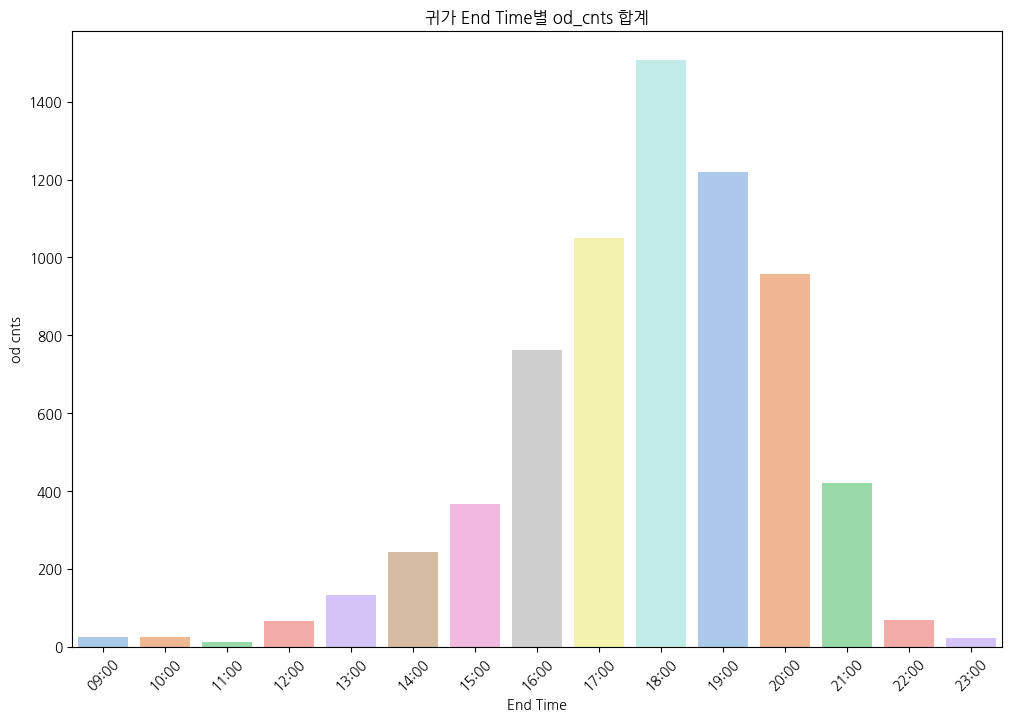

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns

# end_time별로 od_cnts 합산
end_time_counts = dff_I_date.groupby('end_time')['od_cnts'].sum().reset_index()

# 상위 빈도순으로 시각화
plt.figure(figsize=(12, 8))
sns.barplot(x='end_time', y='od_cnts', data=end_time_counts, palette="pastel")
plt.title('귀가 End Time별 od_cnts 합계')
plt.xlabel('End Time')
plt.ylabel('od cnts')
plt.xticks(rotation=45)  # x축 레이블 회전
plt.show()

<ipython-input-64-f069cf5bc543>:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(x='modal', y='end_time', data=dff_I_date, jitter=True, palette="pastel")


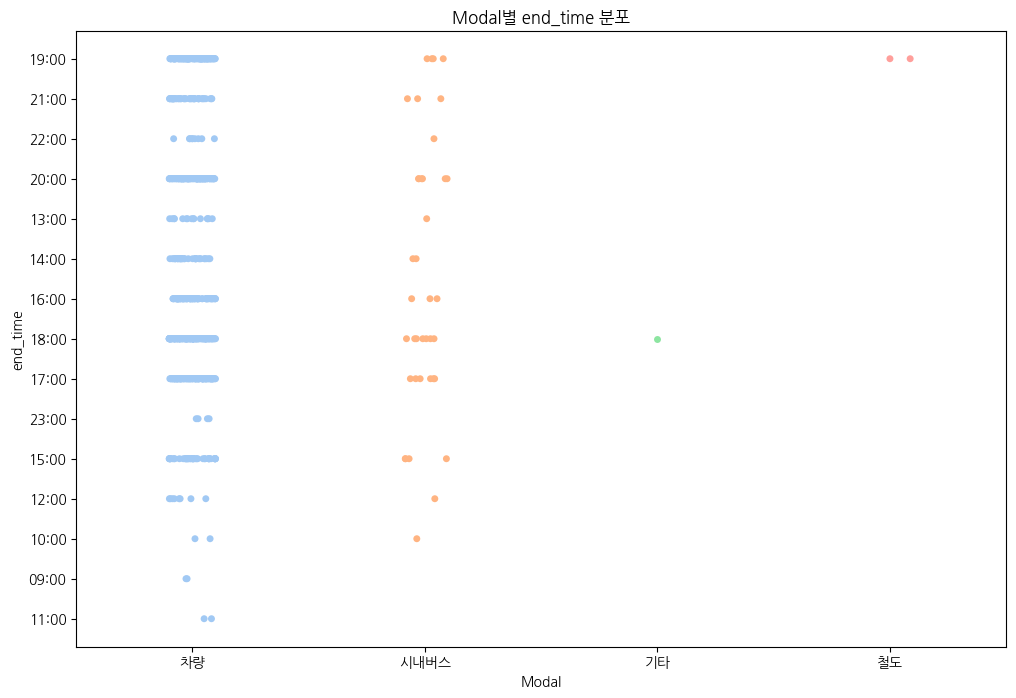

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns

# 그래프 크기 설정
plt.figure(figsize=(12, 8))

# modal별 od_dist_avg 분포를 시각화
sns.stripplot(x='modal', y='end_time', data=dff_I_date, jitter=True, palette="pastel")

# 그래프 제목과 축 레이블 설정
plt.title('Modal별 end_time 분포')
plt.xlabel('Modal')
plt.ylabel('end_time')

plt.show()

# 부산

In [65]:
df_b = df[df['출발지역'] == '부산광역시 해운대구 우2동']
df_b

,origin_hdong_cd,dest_hdong_cd,date,start_time,end_time,gender,age,modal,origin_purpose,dest_purpose,od_dist_avg,od_duration_avg,od_cnts,출발지역
1990,2635052000,4831039000,20230901,19:00,22:00,1.0,3.0,차량,기타,여행,319689.0,170.0,7.0,부산광역시 해운대구 우2동
4573,2635052000,2620064000,20230901,14:00,15:00,0.0,4.0,차량,기타,기타,108069.0,49.0,8.0,부산광역시 해운대구 우2동
5444,2635052000,2635051000,20230901,11:00,11:00,1.0,1.0,차량,여행,여행,38530.0,27.0,14.0,부산광역시 해운대구 우2동
5881,2635052000,2635051000,20230901,19:00,19:00,1.0,1.0,차량,기타,쇼핑여가,22282.0,14.0,7.0,부산광역시 해운대구 우2동
11167,2635052000,2626052000,20230901,19:00,20:00,1.0,3.0,차량,쇼핑여가,쇼핑여가,50249.0,54.0,7.0,부산광역시 해운대구 우2동
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
710973,2635052000,2653059100,20231015,15:00,16:00,0.0,2.0,지하철,여행,여행,38757.0,47.0,6.0,부산광역시 해운대구 우2동
711330,2635052000,2635051000,20231015,18:00,18:00,0.0,2.0,시내버스,기타,기타,12077.0,13.0,5.0,부산광역시 해운대구 우2동
713624,2635052000,2647072000,20231015,19:00,19:00,1.0,2.0,차량,쇼핑여가,기타,30006.0,44.0,5.0,부산광역시 해운대구 우2동
713848,2635052000,2635051000,20231015,14:00,15:00,0.0,3.0,도보,기타,기타,27033.0,62.0,5.0,부산광역시 해운대구 우2동


In [66]:
df_b_date=df_b[(df_b['date']>= 20231004) & (df_b['date'] <= 20231013)]
df_b_date

,origin_hdong_cd,dest_hdong_cd,date,start_time,end_time,gender,age,modal,origin_purpose,dest_purpose,od_dist_avg,od_duration_avg,od_cnts,출발지역
185113,2635052000,2620067000,20231004,11:00,14:00,0.0,2.0,차량,여행,여행,121130.0,186.0,12.0,부산광역시 해운대구 우2동
192087,2635052000,2635051000,20231004,16:00,17:00,0.0,2.0,차량,여행,여행,41218.0,35.0,9.0,부산광역시 해운대구 우2동
201963,2635052000,2650075000,20231004,17:00,18:00,1.0,5.0,차량,쇼핑여가,쇼핑여가,29298.0,42.0,8.0,부산광역시 해운대구 우2동
204254,2635052000,2635051000,20231004,18:00,19:00,0.0,5.0,차량,여행,여행,49733.0,37.0,13.0,부산광역시 해운대구 우2동
204881,2635052000,2635051000,20231004,15:00,16:00,1.0,1.0,차량,기타,쇼핑여가,11172.0,25.0,14.0,부산광역시 해운대구 우2동
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
355927,2635052000,2635051000,20231013,13:00,14:00,1.0,3.0,차량,여행,여행,21333.0,54.0,5.0,부산광역시 해운대구 우2동
356140,2635052000,2635066000,20231013,17:00,18:00,1.0,2.0,시내버스,기타,기타,22969.0,27.0,5.0,부산광역시 해운대구 우2동
357751,2635052000,2623071000,20231013,15:00,17:00,1.0,2.0,지하철,쇼핑여가,기타,97553.0,104.0,5.0,부산광역시 해운대구 우2동
357991,2635052000,2635051000,20231013,16:00,16:00,0.0,3.0,차량,여행,여행,21862.0,17.0,5.0,부산광역시 해운대구 우2동


In [67]:
df_filtered_b=df_b_date[df_b_date['od_dist_avg'] <= 10000]
df_filtered_b

,origin_hdong_cd,dest_hdong_cd,date,start_time,end_time,gender,age,modal,origin_purpose,dest_purpose,od_dist_avg,od_duration_avg,od_cnts,출발지역
223399,2635052000,2650075000,20231004,17:00,17:00,0.0,2.0,차량,쇼핑여가,쇼핑여가,6729.0,6.0,20.0,부산광역시 해운대구 우2동
232836,2635052000,2650073000,20231004,20:00,20:00,1.0,3.0,차량,여행,여행,5074.0,8.0,10.0,부산광역시 해운대구 우2동
233069,2635052000,2635052500,20231004,10:00,10:00,1.0,2.0,차량,여행,여행,5291.0,12.0,10.0,부산광역시 해운대구 우2동
234289,2635052000,2635065000,20231004,16:00,16:00,0.0,3.0,차량,쇼핑여가,쇼핑여가,4501.0,16.0,7.0,부산광역시 해운대구 우2동
257953,2635052000,2635052500,20231004,20:00,20:00,1.0,2.0,차량,기타,기타,2955.0,4.0,10.0,부산광역시 해운대구 우2동
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
326259,2635052000,2635051000,20231013,16:00,16:00,0.0,4.0,시내버스,기타,기타,7770.0,12.0,5.0,부산광역시 해운대구 우2동
328815,2635052000,2635051000,20231013,17:00,17:00,1.0,4.0,차량,기타,기타,6429.0,20.0,5.0,부산광역시 해운대구 우2동
345406,2635052000,2650073000,20231013,17:00,17:00,1.0,5.0,차량,쇼핑여가,쇼핑여가,9080.0,13.0,5.0,부산광역시 해운대구 우2동
350708,2635052000,2635051000,20231013,12:00,12:00,1.0,2.0,차량,여행,여행,7971.0,11.0,5.0,부산광역시 해운대구 우2동


<ipython-input-68-25f5da1c33df>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dest_counts.index, y=dest_counts.values, palette="pastel")


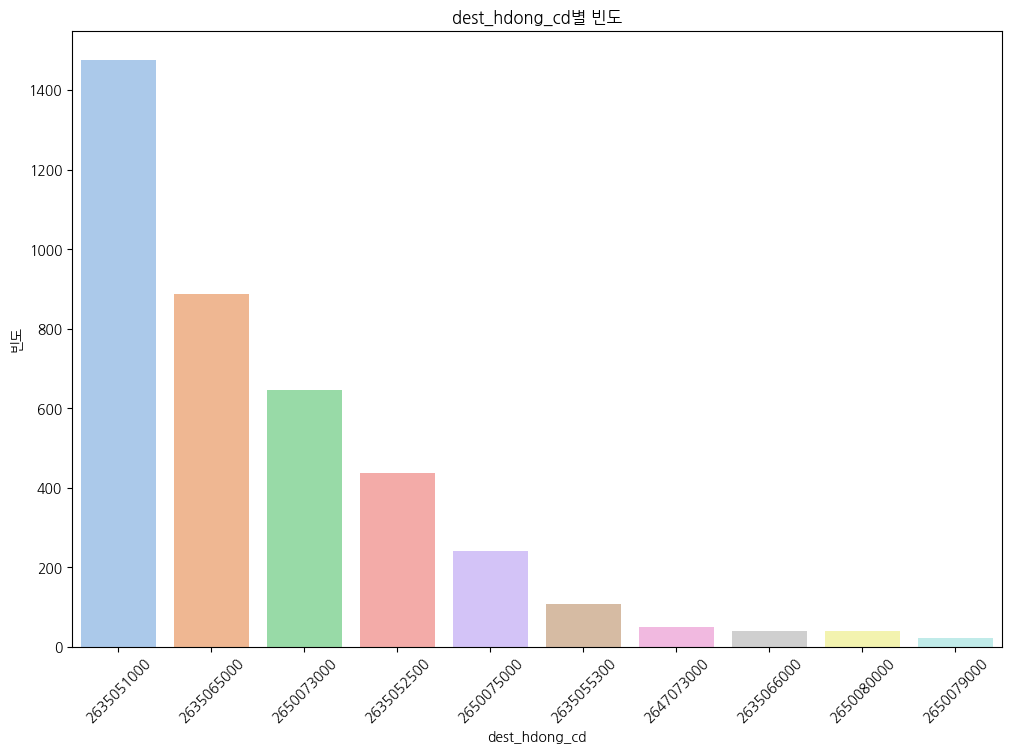

In [68]:
import matplotlib.pyplot as plt
import seaborn as sns

# dest_hdong_cd별 빈도 계산
dest_counts = df_filtered_b['dest_hdong_cd'].value_counts().head(10)

# 막대 그래프로 시각화
plt.figure(figsize=(12, 8))
sns.barplot(x=dest_counts.index, y=dest_counts.values, palette="pastel")
plt.title('dest_hdong_cd별 빈도')
plt.xlabel('dest_hdong_cd')
plt.ylabel('빈도')
plt.xticks(rotation=45)
plt.show()

In [69]:
dff_b = dff[dff['출발지역'] == '부산광역시 해운대구 우2동']
dff_b

,origin_hdong_cd,dest_hdong_cd,date,start_time,end_time,gender,age,modal,origin_purpose,dest_purpose,od_dist_avg,od_duration_avg,od_cnts,출발지역
13705,2635052000,2635065000,20230901,16:00,17:00,1.0,4.0,차량,쇼핑여가,귀가,37434.0,37.0,9.0,부산광역시 해운대구 우2동
13764,2635052000,2629057000,20230901,13:00,13:00,1.0,4.0,차량,쇼핑여가,귀가,31322.0,24.0,10.0,부산광역시 해운대구 우2동
14786,2635052000,2614066000,20230901,13:00,14:00,1.0,3.0,차량,쇼핑여가,귀가,73944.0,50.0,9.0,부산광역시 해운대구 우2동
15373,2635052000,2635051000,20230901,17:00,17:00,0.0,0.0,차량,기타,귀가,13780.0,12.0,40.0,부산광역시 해운대구 우2동
16479,2635052000,2635055300,20230901,16:00,17:00,0.0,2.0,기타,기타,귀가,29651.0,44.0,7.0,부산광역시 해운대구 우2동
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
707911,2635052000,2629070000,20231015,19:00,19:00,1.0,3.0,차량,기타,귀가,47528.0,35.0,5.0,부산광역시 해운대구 우2동
710897,2635052000,2635052500,20231015,19:00,19:00,1.0,2.0,시내버스,기타,귀가,20837.0,32.0,5.0,부산광역시 해운대구 우2동
712253,2635052000,2629058000,20231015,22:00,23:00,1.0,3.0,차량,기타,귀가,195659.0,91.0,6.0,부산광역시 해운대구 우2동
713609,2635052000,2629064500,20231015,18:00,19:00,1.0,5.0,차량,기타,귀가,25823.0,23.0,6.0,부산광역시 해운대구 우2동


In [70]:
dff_b_date=dff_b[(dff_b['date']>= 20231004) & (dff_b['date'] <= 20231013)]
dff_b_date

,origin_hdong_cd,dest_hdong_cd,date,start_time,end_time,gender,age,modal,origin_purpose,dest_purpose,od_dist_avg,od_duration_avg,od_cnts,출발지역
176087,2635052000,2671025300,20231004,15:00,17:00,1.0,1.0,차량,기타,귀가,162896.0,130.0,14.0,부산광역시 해운대구 우2동
176885,2635052000,2650080000,20231004,17:00,17:00,0.0,0.0,차량,쇼핑여가,귀가,36828.0,28.0,12.0,부산광역시 해운대구 우2동
179412,2635052000,2635055200,20231004,15:00,15:00,0.0,1.0,시내버스,기타,귀가,19686.0,32.0,13.0,부산광역시 해운대구 우2동
190650,2635052000,4833025300,20231004,14:00,15:00,1.0,1.0,차량,쇼핑여가,귀가,97375.0,51.0,15.0,부산광역시 해운대구 우2동
194868,2635052000,2635065000,20231004,16:00,16:00,1.0,3.0,차량,쇼핑여가,귀가,6131.0,8.0,8.0,부산광역시 해운대구 우2동
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
342139,2635052000,2635066000,20231013,12:00,13:00,0.0,1.0,시내버스,기타,귀가,14378.0,37.0,5.0,부산광역시 해운대구 우2동
343165,2635052000,2635061000,20231013,15:00,16:00,1.0,5.0,차량,쇼핑여가,귀가,43316.0,68.0,5.0,부산광역시 해운대구 우2동
344037,2635052000,2635065000,20231013,22:00,23:00,0.0,1.0,차량,쇼핑여가,귀가,19675.0,41.0,5.0,부산광역시 해운대구 우2동
353164,2635052000,2650073000,20231013,13:00,14:00,1.0,5.0,지하철,쇼핑여가,귀가,6989.0,16.0,5.0,부산광역시 해운대구 우2동


<ipython-input-71-b795e3a24b72>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='end_time', y='od_cnts', data=end_time_counts, palette="pastel")


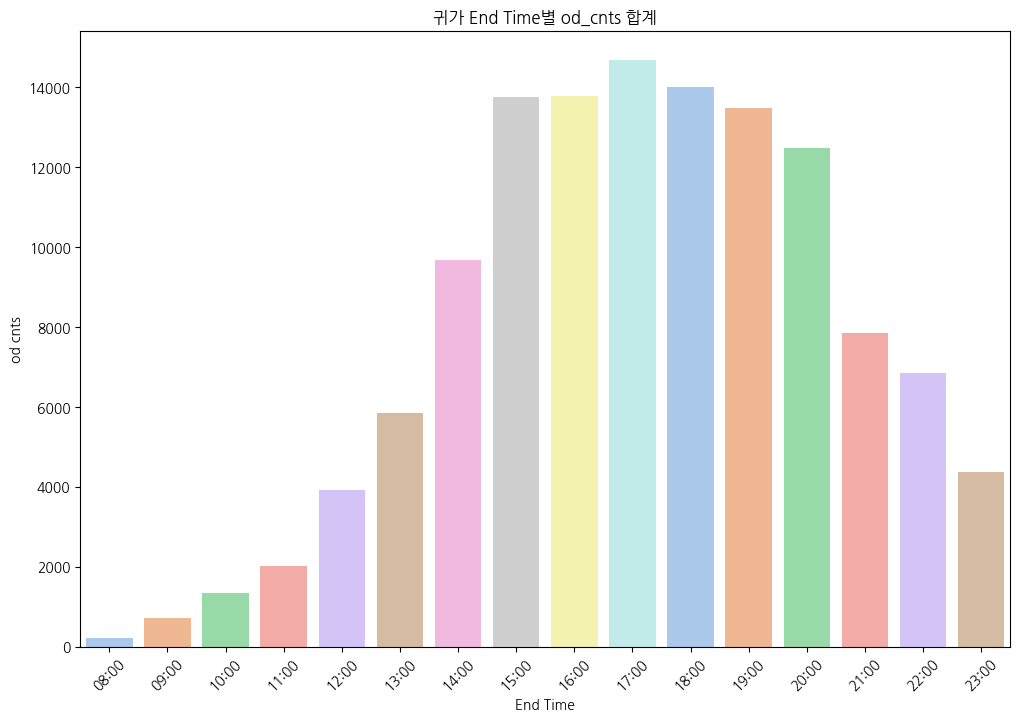

In [71]:
import matplotlib.pyplot as plt
import seaborn as sns

# end_time별로 od_cnts 합산
end_time_counts = dff_b_date.groupby('end_time')['od_cnts'].sum().reset_index()

# 상위 빈도순으로 시각화
plt.figure(figsize=(12, 8))
sns.barplot(x='end_time', y='od_cnts', data=end_time_counts, palette="pastel")
plt.title('귀가 End Time별 od_cnts 합계')
plt.xlabel('End Time')
plt.ylabel('od cnts')
plt.xticks(rotation=45)  # x축 레이블 회전
plt.show()


<ipython-input-72-f7f1f7369e9a>:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(x='modal', y='end_time', data=dff_b_date, jitter=True, palette="pastel")


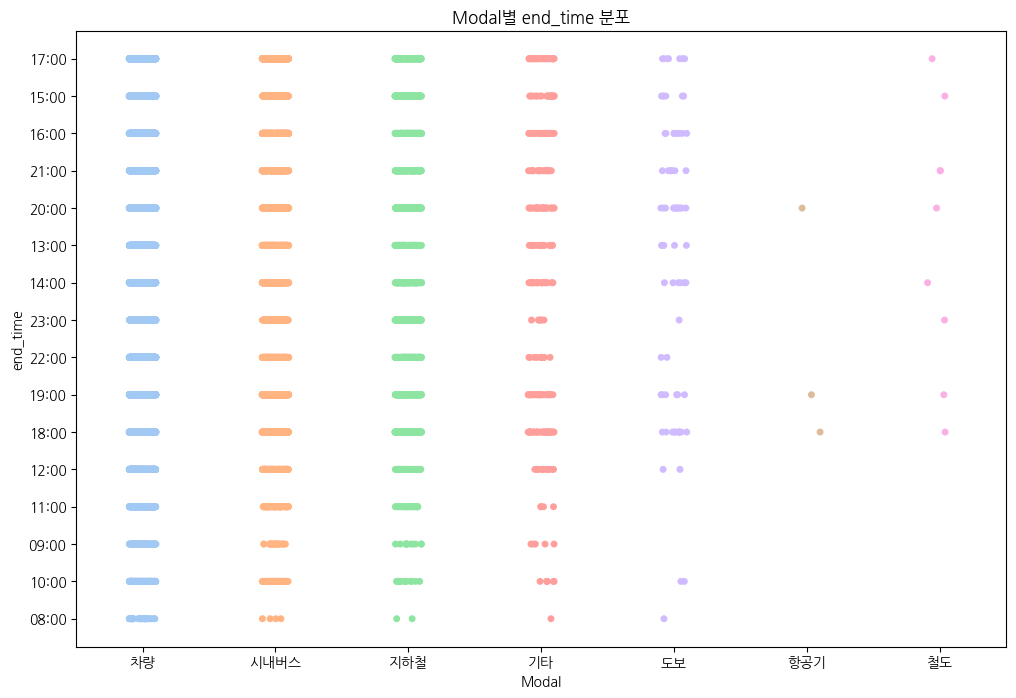

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns

# 그래프 크기 설정
plt.figure(figsize=(12, 8))

# modal별 od_dist_avg 분포를 시각화
sns.stripplot(x='modal', y='end_time', data=dff_b_date, jitter=True, palette="pastel")

# 그래프 제목과 축 레이블 설정
plt.title('Modal별 end_time 분포')
plt.xlabel('Modal')
plt.ylabel('end_time')

plt.show()

# 여의도

In [73]:
df_s = df[df['출발지역'] == '여의동']
df_s

,origin_hdong_cd,dest_hdong_cd,date,start_time,end_time,gender,age,modal,origin_purpose,dest_purpose,od_dist_avg,od_duration_avg,od_cnts,출발지역
330,1156054000,4180032000,20230901,16:00,20:00,1.0,2.0,차량,기타,여행,234893.0,233.0,8.0,여의동
8293,1156054000,1144066000,20230901,15:00,16:00,1.0,2.0,차량,쇼핑여가,쇼핑여가,30630.0,58.0,7.0,여의동
20435,1156054000,4113366000,20230901,18:00,20:00,0.0,2.0,지하철,기타,기타,79322.0,93.0,7.0,여의동
21952,1156054000,4157034000,20230901,17:00,19:00,0.0,3.0,차량,기타,기타,94898.0,111.0,28.0,여의동
26290,1156054000,4511170100,20230901,18:00,22:00,0.0,2.0,차량,기타,여행,603727.0,264.0,10.0,여의동
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
697388,1156054000,1111065000,20231015,15:00,17:00,1.0,1.0,시내버스,기타,쇼핑여가,113066.0,131.0,5.0,여의동
701484,1156054000,1165062000,20231015,15:00,16:00,1.0,3.0,차량,쇼핑여가,쇼핑여가,25626.0,46.0,5.0,여의동
701506,1156054000,1159068000,20231015,12:00,12:00,1.0,3.0,차량,여행,여행,14857.0,16.0,5.0,여의동
705414,1156054000,1153055000,20231015,17:00,18:00,0.0,2.0,차량,기타,기타,9942.0,59.0,5.0,여의동


In [75]:
df_s_date=df_s[df_s['date'] == 20231007]
df_s_date

,origin_hdong_cd,dest_hdong_cd,date,start_time,end_time,gender,age,modal,origin_purpose,dest_purpose,od_dist_avg,od_duration_avg,od_cnts,출발지역
293434,1156054000,1144058500,20231007,20:00,21:00,1.0,4.0,시내버스,쇼핑여가,쇼핑여가,38561.0,32.0,8.0,여의동
293552,1156054000,1141058500,20231007,20:00,21:00,0.0,2.0,차량,기타,기타,36324.0,63.0,8.0,여의동
293774,1156054000,1156051500,20231007,21:00,21:00,1.0,2.0,차량,기타,기타,30909.0,42.0,12.0,여의동
293999,1156054000,1171056200,20231007,20:00,22:00,0.0,1.0,차량,여행,여행,92643.0,121.0,13.0,여의동
295190,1156054000,1168052100,20231007,20:00,22:00,1.0,3.0,지하철,기타,기타,76703.0,104.0,8.0,여의동
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
266254,1156054000,1150060300,20231007,21:00,22:00,0.0,2.0,차량,여행,여행,63171.0,67.0,5.0,여의동
267588,1156054000,1123056000,20231007,17:00,18:00,0.0,4.0,지하철,쇼핑여가,쇼핑여가,41597.0,63.0,5.0,여의동
267854,1156054000,4121062000,20231007,13:00,14:00,0.0,3.0,차량,여행,기타,46197.0,63.0,5.0,여의동
269941,1156054000,4113156100,20231007,20:00,23:00,1.0,4.0,차량,기타,기타,140331.0,194.0,5.0,여의동


In [76]:
df_filtered_s=df_s_date[df_s_date['od_dist_avg'] <= 10000]
df_filtered_s

,origin_hdong_cd,dest_hdong_cd,date,start_time,end_time,gender,age,modal,origin_purpose,dest_purpose,od_dist_avg,od_duration_avg,od_cnts,출발지역
296728,1156054000,1159052000,20231007,19:00,19:00,0.0,2.0,차량,쇼핑여가,쇼핑여가,6854.0,14.0,11.0,여의동
304202,1156054000,1156056000,20231007,18:00,19:00,1.0,0.0,차량,쇼핑여가,기타,8994.0,23.0,35.0,여의동
315145,1156054000,1117057000,20231007,20:00,20:00,1.0,0.0,차량,기타,쇼핑여가,4491.0,14.0,23.0,여의동
325882,1156054000,1159068000,20231007,20:00,21:00,1.0,0.0,차량,여행,쇼핑여가,4773.0,49.0,37.0,여의동
346110,1156054000,1159051000,20231007,18:00,18:00,0.0,3.0,차량,쇼핑여가,쇼핑여가,5892.0,7.0,9.0,여의동
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
215075,1156054000,1117064000,20231007,18:00,18:00,0.0,5.0,차량,여행,여행,4385.0,11.0,5.0,여의동
216223,1156054000,1117057000,20231007,15:00,15:00,1.0,4.0,차량,여행,여행,5112.0,8.0,5.0,여의동
236104,1156054000,1156053500,20231007,21:00,22:00,0.0,1.0,시내버스,쇼핑여가,쇼핑여가,7134.0,11.0,5.0,여의동
253228,1156054000,1144058500,20231007,18:00,18:00,1.0,2.0,차량,쇼핑여가,쇼핑여가,5655.0,29.0,6.0,여의동


<ipython-input-77-4af6a8cd7ca6>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dest_counts.index, y=dest_counts.values, palette="pastel")


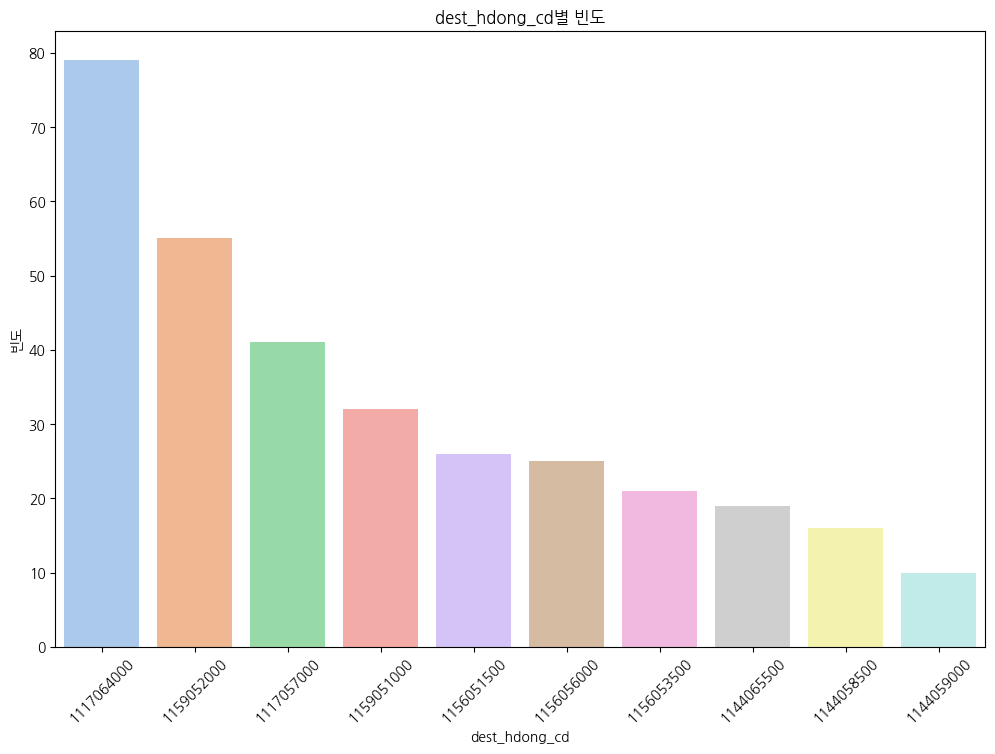

In [77]:
import matplotlib.pyplot as plt
import seaborn as sns

# dest_hdong_cd별 빈도 계산
dest_counts = df_filtered_s['dest_hdong_cd'].value_counts().head(10)

# 막대 그래프로 시각화
plt.figure(figsize=(12, 8))
sns.barplot(x=dest_counts.index, y=dest_counts.values, palette="pastel")
plt.title('dest_hdong_cd별 빈도')
plt.xlabel('dest_hdong_cd')
plt.ylabel('빈도')
plt.xticks(rotation=45)
plt.show()

In [78]:
dff_s = dff[dff['출발지역'] == '여의동']
dff_s

,origin_hdong_cd,dest_hdong_cd,date,start_time,end_time,gender,age,modal,origin_purpose,dest_purpose,od_dist_avg,od_duration_avg,od_cnts,출발지역
13179,1156054000,4623036000,20230901,17:00,22:00,1.0,2.0,차량,여행,귀가,866133.0,322.0,15.0,여의동
14170,1156054000,1156066000,20230901,14:00,15:00,1.0,5.0,차량,쇼핑여가,귀가,40629.0,61.0,7.0,여의동
15546,1156054000,4117353000,20230901,20:00,23:00,1.0,2.0,차량,쇼핑여가,귀가,159282.0,167.0,8.0,여의동
21529,1156054000,1156058500,20230901,15:00,17:00,1.0,5.0,차량,쇼핑여가,귀가,50309.0,84.0,8.0,여의동
21965,1156054000,1159067000,20230901,18:00,19:00,0.0,5.0,차량,쇼핑여가,귀가,33149.0,51.0,9.0,여의동
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
708578,1156054000,2823758100,20231015,14:00,15:00,1.0,1.0,차량,여행,귀가,35586.0,60.0,5.0,여의동
709176,1156054000,4139052000,20231015,21:00,23:00,1.0,2.0,차량,여행,귀가,90806.0,126.0,5.0,여의동
709688,1156054000,1147062000,20231015,17:00,20:00,1.0,1.0,차량,쇼핑여가,귀가,164178.0,172.0,5.0,여의동
710559,1156054000,4139052000,20231015,21:00,22:00,0.0,2.0,차량,기타,귀가,87742.0,99.0,5.0,여의동


In [79]:
dff_s_date = dff_s[dff_s['date'] == 20231007]
dff_s_date

,origin_hdong_cd,dest_hdong_cd,date,start_time,end_time,gender,age,modal,origin_purpose,dest_purpose,od_dist_avg,od_duration_avg,od_cnts,출발지역
292634,1156054000,4111355000,20231007,22:00,23:00,0.0,0.0,차량,쇼핑여가,귀가,61730.0,108.0,14.0,여의동
293444,1156054000,4119061000,20231007,20:00,21:00,1.0,1.0,차량,쇼핑여가,귀가,41569.0,53.0,7.0,여의동
293484,1156054000,4159025900,20231007,20:00,22:00,0.0,3.0,차량,여행,귀가,152736.0,110.0,6.0,여의동
294501,1156054000,1162054500,20231007,20:00,22:00,1.0,0.0,차량,쇼핑여가,귀가,45814.0,102.0,23.0,여의동
295052,1156054000,4413325000,20231007,20:00,23:00,1.0,2.0,철도,여행,귀가,149798.0,195.0,11.0,여의동
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
269666,1156054000,1121573000,20231007,21:00,22:00,1.0,1.0,차량,기타,귀가,21992.0,72.0,5.0,여의동
269956,1156054000,1147062000,20231007,20:00,21:00,0.0,2.0,지하철,기타,귀가,79742.0,101.0,5.0,여의동
270055,1156054000,1150054000,20231007,21:00,22:00,0.0,3.0,차량,쇼핑여가,귀가,25232.0,53.0,5.0,여의동
270131,1156054000,1168061000,20231007,20:00,22:00,0.0,4.0,차량,기타,귀가,125968.0,111.0,5.0,여의동


<ipython-input-80-68f114235e4d>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='end_time', y='od_cnts', data=end_time_counts, palette="pastel")


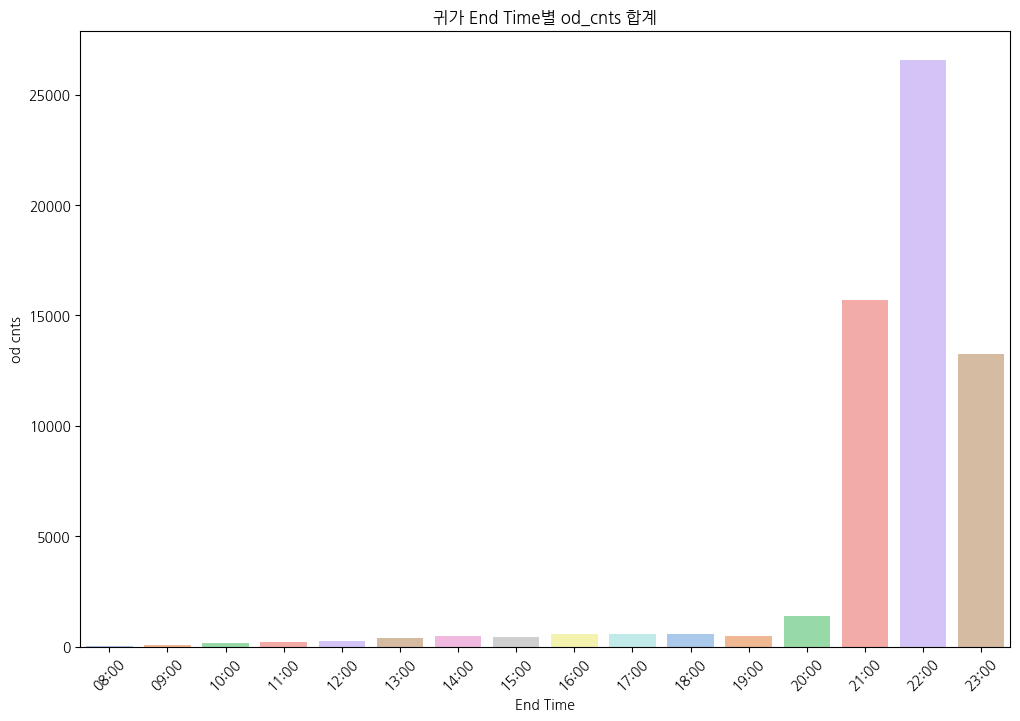

In [80]:
import matplotlib.pyplot as plt
import seaborn as sns

# end_time별로 od_cnts 합산
end_time_counts = dff_s_date.groupby('end_time')['od_cnts'].sum().reset_index()

# 상위 빈도순으로 시각화
plt.figure(figsize=(12, 8))
sns.barplot(x='end_time', y='od_cnts', data=end_time_counts, palette="pastel")
plt.title('귀가 End Time별 od_cnts 합계')
plt.xlabel('End Time')
plt.ylabel('od cnts')
plt.xticks(rotation=45)  # x축 레이블 회전
plt.show()


<ipython-input-81-ad40137ebd1c>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=end_time_counts.index, y=end_time_counts.values, palette="pastel")


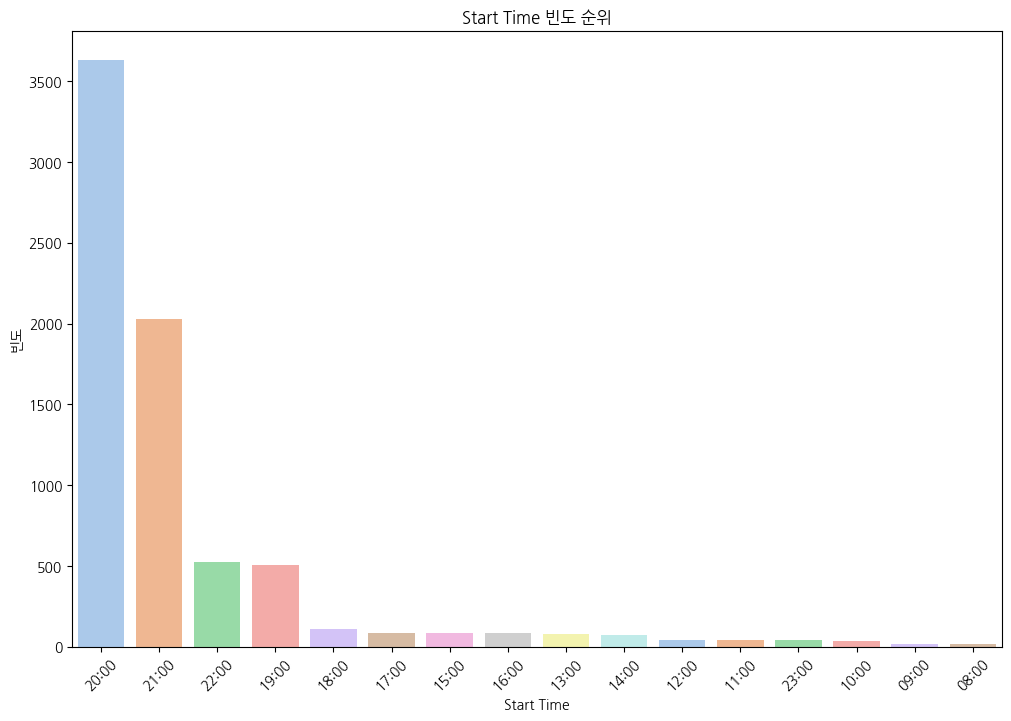

In [81]:
import matplotlib.pyplot as plt
import seaborn as sns

# end_time별 빈도 계산
end_time_counts = dff_s_date['start_time'].value_counts()

# 상위 빈도순으로 시각화
plt.figure(figsize=(12, 8))
sns.barplot(x=end_time_counts.index, y=end_time_counts.values, palette="pastel")
plt.title('Start Time 빈도 순위')
plt.xlabel('Start Time')
plt.ylabel('빈도')
plt.xticks(rotation=45)  # x축 레이블 회전
plt.show()
